# Detección de Clickbait en Prensa Chilena — RoBERTuito
## Informe Técnico — Entrega 2, Modelado Transformer Individual

**Estudiante:** Clara Leighton  
**Grupo:** 2 — Universidad de los Andes  
**Curso:** Inteligencia Artificial Aplicada (IAA)  
**Fecha:** Abril 2026  
**Modelo asignado:** RoBERTa / variante RoBERTa en español  
**Checkpoint utilizado:** `pysentimiento/robertuito-base-uncased`

---
Este notebook implementa el pipeline completo de clasificación de titulares usando **RoBERTuito**, una variante basada en RoBERTa entrenada para texto digital en español. La estructura se mantiene alineada con los notebooks individuales del grupo:

1. Exploración y preprocesamiento de datos  
2. Fine-tuning con early stopping  
3. Manejo del desbalance mediante `WeightedRandomSampler`  
4. Evaluación robusta: Accuracy, F1-macro, F1 por clase y matriz de confusión  
5. Diagnóstico de overfitting  
6. Explicabilidad XAI con LIME y mapas de atención  
7. Comparación transnacional: prensa nacional vs. internacional  
8. Recomendaciones de política pública basadas en evidencia

## 1. Instalación y Configuración

In [ ]:
!pip install -q "transformers>=4.41.0,<5.0.0" datasets torch torchvision
!pip install -q lime shap
!pip install -q scikit-learn pandas numpy matplotlib seaborn
!pip install -q accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 19.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 11.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import os
import re
import json
import logging
import warnings
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from transformers import (
    get_linear_schedule_with_warmup,
    TextClassificationPipeline,
    AutoTokenizer,
    AutoModelForSequenceClassification,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)
from sklearn.utils.class_weight import compute_class_weight
from lime.lime_text import LimeTextExplainer
import shap

warnings.filterwarnings("ignore")

logging.basicConfig(level=logging.INFO, format="[%(levelname)s] %(message)s")
logger = logging.getLogger(__name__)

SEED: int = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info(f"Usando dispositivo: {device}")

## 2. Justificación Técnica del Modelo: RoBERTuito (`pysentimiento/robertuito-base-uncased`)

### ¿Por qué RoBERTuito para esta tarea?

La tarea exige que cada integrante entrene un modelo Transformer distinto y justifique la elección considerando idioma y *domain mismatch*. En este caso se utiliza **RoBERTuito**, una variante basada en la familia RoBERTa, pero adaptada a texto digital en español.

**Arquitectura — relación con RoBERTa:**  
RoBERTuito conserva la lógica de modelos tipo RoBERTa para comprensión de lenguaje, por lo que sigue siendo una alternativa válida dentro de la familia RoBERTa. A diferencia de BERT/BETO, RoBERTa elimina el objetivo de *Next Sentence Prediction* y optimiza el preentrenamiento para tareas de comprensión a nivel de texto, lo cual es pertinente para titulares, ya que cada titular funciona como una unidad textual breve e independiente.

**Idioma — español:**  
El dataset está compuesto por titulares en español, por lo que se requiere un modelo preentrenado en español. Usar un RoBERTa original en inglés aumentaría el desajuste lingüístico. RoBERTuito permite mantener la familia RoBERTa, pero con representaciones aprendidas sobre texto en español.

**Dominio — texto digital y clickbait:**  
El clickbait no depende solamente del contenido factual del titular, sino también de señales propias del ecosistema digital: exageración, emocionalidad, viralidad, preguntas retóricas, verbos de revelación y retención estratégica de información. Por eso, RoBERTuito resulta especialmente pertinente: su preentrenamiento en texto digital puede capturar mejor expresiones como “viral”, “impactante”, “increíble”, “reveló” o “descubre”, previamente identificadas en el EDA como léxico característico del clickbait.

**Domain mismatch esperado:**  
Aunque RoBERTuito está adaptado a texto digital en español, no fue preentrenado específicamente sobre titulares de prensa chilena. Por lo tanto, pueden existir desajustes frente a:
- modismos locales chilenos;
- nombres de medios, figuras públicas o instituciones nacionales;
- estilos editoriales propios de portales chilenos;
- diferencias entre clickbait nacional e internacional.

El análisis XAI y la comparación transnacional permiten evaluar si este desajuste afecta la detección de clickbait en Chile respecto de la prensa internacional.

## 3. Carga y Exploración del Dataset

In [ ]:
import os

candidate_paths = [
    "dataset_etiquetado_v3.csv",
    "../dataset_output/dataset_etiquetado_v3.csv",
    "/content/dataset_etiquetado_v3.csv",
    "/content/drive/MyDrive/dataset_etiquetado_v3.csv",
]

DATA_PATH = None
for p in candidate_paths:
    if os.path.exists(p):
        DATA_PATH = p
        break

if DATA_PATH is None:
    try:
        from google.colab import files
        print("Sube el archivo dataset_etiquetado_v3.csv:")
        uploaded = files.upload()
        DATA_PATH = list(uploaded.keys())[0]
    except ImportError:
        raise FileNotFoundError(
            "No se encontró dataset_etiquetado_v3.csv. "
            "Colócalo en el mismo directorio que este notebook."
        )

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
logger.info(f"Dataset cargado desde: {DATA_PATH}")

n_total = len(df)
n_cols = df.shape[1]
class_counts = df["etiqueta_final"].value_counts()
class_pcts = (class_counts / n_total * 100).round(1)

logger.info(f"Dataset: {n_total} titulares | {n_cols} columnas")
logger.info(f"Columnas: {df.columns.tolist()}")

print("\nDISTRIBUCION DE CLASES")
print("-" * 50)
for cls in class_counts.index:
    cnt = class_counts[cls]
    pct = class_pcts[cls]
    bar = "#" * int(pct / 2)
    print(f"  {cls:<15}: {cnt:>5} ({pct:>5.1f}%)  {bar}")
print("-" * 50)

minority_class = class_counts.idxmin()
majority_class = class_counts.idxmax()
imbalance_ratio = class_counts[majority_class] / class_counts[minority_class]
print(f"\n Ratio de desbalance {majority_class}/{minority_class}: {imbalance_ratio:.1f}x")
print(f" Métrica principal: F1-macro (penaliza clases minoritarias ignoradas)")

df.head(5)

Sube el archivo dataset_etiquetado_v3.csv:


Saving dataset_etiquetado_v3.csv to dataset_etiquetado_v3.csv

DISTRIBUCION DE CLASES
--------------------------------------------------
  informativo    :  4014 ( 75.3%)  #####################################
  fake_news      :  1002 ( 18.8%)  #########
  clickbait      :   317 (  5.9%)  ##
--------------------------------------------------

 Ratio de desbalance informativo/clickbait: 12.7x
 Métrica principal: F1-macro (penaliza clases minoritarias ignoradas)


,titulo,url,fecha_publicacion,portal,origen,etiqueta_base,cb_heuristic,cb_brecha,cb_exageracion,cb_emocion,cb_ambiguedad,cb_eje_dominante,etiqueta_final,metodo_obtencion
0,"Jorge Segovia, dueño de Unión Española: “Nuest...",https://news.google.com/rss/articles/CBMi3AFBV...,"Sun, 19 Apr 2026 01:14:38 GMT",La Tercera,nacional,informativo,0.000,0.0,0.0,0.0,0.0,ninguno,informativo,gnews_rss
1,Rodrigo Valdés (FMI) y alzas de bencinas: “El ...,https://news.google.com/rss/articles/CBMiogJBV...,"Sun, 19 Apr 2026 11:00:00 GMT",La Tercera,nacional,informativo,0.000,0.0,0.0,0.0,0.0,ninguno,informativo,gnews_rss
2,Cambio histórico en la UC: Matías Claro asume ...,https://news.google.com/rss/articles/CBMi4gFBV...,"Mon, 20 Apr 2026 19:30:56 GMT",La Tercera,nacional,informativo,0.125,0.0,0.5,0.0,0.0,exageracion,informativo,gnews_rss
3,El cerebro tras el origen de Cruzados: quién e...,https://news.google.com/rss/articles/CBMi8AFBV...,"Mon, 20 Apr 2026 17:30:39 GMT",La Tercera,nacional,informativo,0.125,0.0,0.5,0.0,0.0,exageracion,informativo,gnews_rss
4,“No los aguantamos”: la anécdota entre Diego L...,https://news.google.com/rss/articles/CBMi8gFBV...,"Mon, 20 Apr 2026 11:18:36 GMT",La Tercera,nacional,informativo,0.000,0.0,0.0,0.0,0.0,ninguno,informativo,gnews_rss


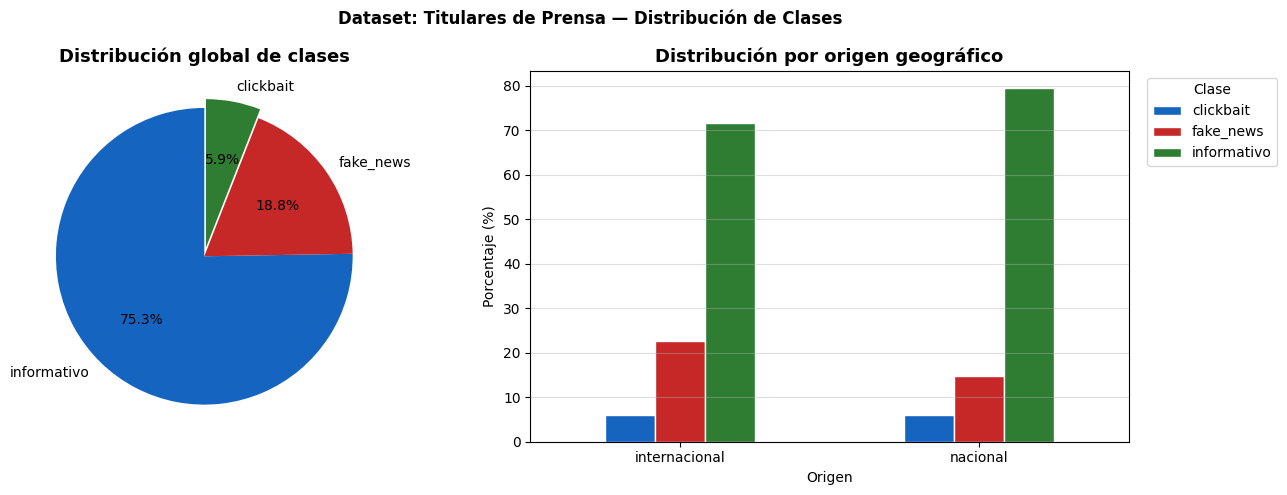


Distribución por origen:
etiqueta_final  clickbait  fake_news  informativo
origen                                           
internacional         165        628         1992
nacional              152        374         2022


In [ ]:
palette = ["#1565C0", "#C62828", "#2E7D32", "#6A1B9A", "#E65100"]
classes_ordered = class_counts.index.tolist()
colors = palette[: len(classes_ordered)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
explode = [0.06 if c == minority_class else 0 for c in classes_ordered]
axes[0].pie(
    class_counts.values,
    labels=class_counts.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    explode=explode,
)
axes[0].set_title("Distribución global de clases", fontsize=13, fontweight="bold")

# Barras por origen geográfico
pivot = df.groupby(["origen", "etiqueta_final"]).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct.plot(kind="bar", ax=axes[1], color=colors, edgecolor="white", rot=0)
axes[1].set_title("Distribución por origen geográfico", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Origen")
axes[1].set_ylabel("Porcentaje (%)")
axes[1].legend(title="Clase", bbox_to_anchor=(1.02, 1))
axes[1].grid(axis="y", alpha=0.4)

plt.suptitle("Dataset: Titulares de Prensa — Distribución de Clases", fontweight="bold")
plt.tight_layout()
plt.savefig("01_distribucion_clases.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nDistribución por origen:")
print(df.groupby(["origen", "etiqueta_final"]).size().unstack(fill_value=0))

Estadísticas de longitud (palabras) por clase:
                 count   mean   std  min   25%   50%   75%   max
etiqueta_final                                                  
clickbait        317.0  14.79  4.33  3.0  12.0  15.0  18.0  33.0
fake_news       1002.0  15.53  5.75  2.0  12.0  15.0  18.0  40.0
informativo     4014.0  13.82  4.96  1.0  11.0  14.0  17.0  37.0


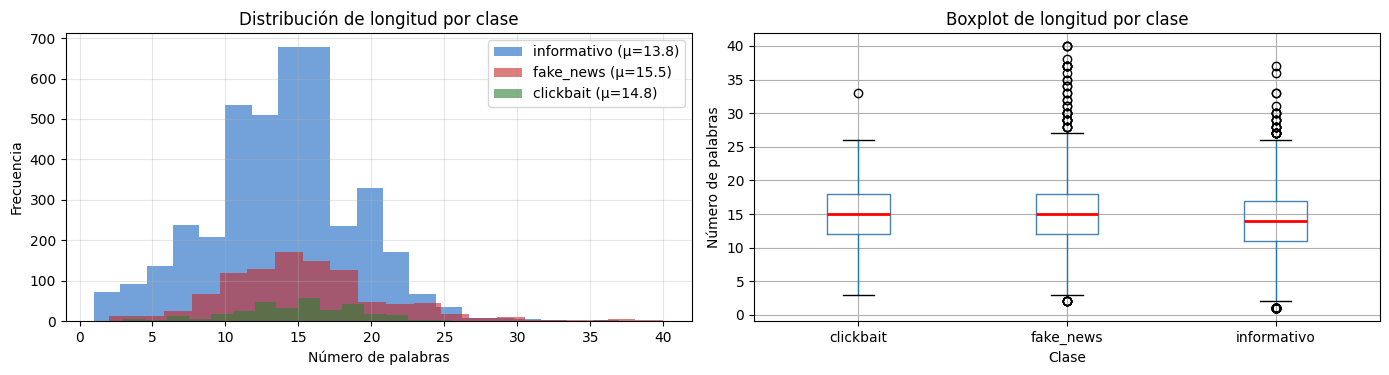


 Los titulares clickbait son en promedio 1.0 palabras más largos que los informativos.


In [ ]:
# Análisis de longitud de titulares por clase
df["n_palabras"] = df["titulo"].astype(str).apply(lambda x: len(x.split()))
df["n_chars"] = df["titulo"].astype(str).apply(len)

stats = df.groupby("etiqueta_final")["n_palabras"].describe().round(2)
print("Estadísticas de longitud (palabras) por clase:")
print(stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for clase, color in zip(classes_ordered, colors):
    subset = df[df["etiqueta_final"] == clase]["n_palabras"]
    mu = subset.mean()
    axes[0].hist(subset, bins=20, alpha=0.6, color=color, label=f"{clase} (μ={mu:.1f})")
axes[0].set_title("Distribución de longitud por clase")
axes[0].set_xlabel("Número de palabras")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()
axes[0].grid(alpha=0.3)

df.boxplot(
    column="n_palabras", by="etiqueta_final", ax=axes[1],
    boxprops=dict(color="steelblue"),
    medianprops=dict(color="red", linewidth=2),
)
axes[1].set_title("Boxplot de longitud por clase")
axes[1].set_xlabel("Clase")
axes[1].set_ylabel("Número de palabras")
plt.suptitle("")
plt.tight_layout()
plt.savefig("02_longitud_titulares.png", dpi=120, bbox_inches="tight")
plt.show()

mean_cb = df[df["etiqueta_final"] == "clickbait"]["n_palabras"].mean()
mean_inf = df[df["etiqueta_final"] == "informativo"]["n_palabras"].mean()
diff = mean_cb - mean_inf
print(f"\n Los titulares clickbait son en promedio {abs(diff):.1f} palabras "
      f"{'más largos' if diff > 0 else 'más cortos'} que los informativos.")

In [ ]:
print("EJEMPLOS DE TITULARES POR CLASE\n")
print("=" * 80)
for clase in classes_ordered:
    print(f"\n  CLASE: {clase.upper()}")
    print("  " + "-" * 70)
    ejemplos = (
        df[df["etiqueta_final"] == clase]["titulo"]
        .sample(3, random_state=SEED)
        .tolist()
    )
    for j, ej in enumerate(ejemplos, 1):
        print(f"  {j}. {ej}")

EJEMPLOS DE TITULARES POR CLASE


  CLASE: INFORMATIVO
  ----------------------------------------------------------------------
  1. El final secreto de 'Smallville': Tom Welling revela lo que realmente iba a pasar con Clark Kent
  2. Verificación: Trump no ha anunciado multas o cárcel por hablar español en EEUU
  3. España recibió casi 22,4 millones de pasajeros internacionales hasta marzo, un 5,8 % más - EFE

  CLASE: FAKE_NEWS
  ----------------------------------------------------------------------
  1. Los bulos no descansan en 2025, pero tampoco Newtral: más de 150 talleres y proyectos para luchar contra la desinformación
  2. Falso nexo de un familiar de la senadora Cabal con la masacre de las Bananeras es una mentira vieja
  3. El hombre detrás de una estrategia de desinformación rusa en América Latina

  CLASE: CLICKBAIT
  ----------------------------------------------------------------------
  1. VIDEO VIRAL: niño extraterrestre en campaña contra el "bullying" de UNICEF
  2. C

## 4. Preprocesamiento de Texto

### Decisiones de preprocesamiento para RoBERTuito

RoBERTuito usa tokenización de subpalabras compatible con modelos tipo RoBERTa. Por eso, se realiza una limpieza mínima:

- **Se preservan:** tildes, signos `?!`, comillas y estructura original del titular.
- **Se eliminan:** URLs, emojis, caracteres de control, hashtags y menciones `@`.
- **No se aplica:** stemming ni lematización, porque el tokenizer ya divide en subpalabras.

Esta estrategia minimiza la pérdida de señal lingüística relevante para detectar clickbait: exclamaciones, preguntas retóricas, verbos de revelación, adjetivos hiperbólicos y palabras emocionales.

In [ ]:
def preprocess_titulo(texto: str) -> str:

    if not isinstance(texto, str):
        return ""
    texto = re.sub(r"https?://\S+|www\.\S+", "", texto)
    texto = re.sub(r"[\U00010000-\U0010ffff]", "", texto, flags=re.UNICODE)
    texto = re.sub(r"#\w+|@\w+", "", texto)
    texto = re.sub(r"[\x00-\x1f\x7f-\x9f]", "", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

df["titulo_clean"] = df["titulo"].apply(preprocess_titulo)

n_antes = len(df)
df = df[df["titulo_clean"].str.len() > 5].reset_index(drop=True)
n_eliminados = n_antes - len(df)
logger.info(f"Preprocesamiento: {n_antes} → {len(df)} titulares | {n_eliminados} eliminados por longitud insuficiente.")

n_modificados = (df["titulo"] != df["titulo_clean"]).sum()
print(f"\n{n_modificados} titulares modificados por el preprocesamiento.")
cambios = df[df["titulo"] != df["titulo_clean"]].head(3)
if len(cambios) > 0:
    for _, row in cambios.iterrows():
        print(f"  ANTES  : {row['titulo'][:100]}")
        print(f"  DESPUÉS: {row['titulo_clean'][:100]}\n")


18 titulares modificados por el preprocesamiento.
  ANTES  : www.lun.com - Diario Las Ultimas Noticias
  DESPUÉS: - Diario Las Ultimas Noticias

  ANTES  : #CómoLoHizo: JumpCar, un espacio de entretención para los niños
  DESPUÉS: : JumpCar, un espacio de entretención para los niños

  ANTES  : #2020Challenge: El nuevo reto viral que muestra nuestras emociones en este año
  DESPUÉS: : El nuevo reto viral que muestra nuestras emociones en este año



## 5. División Estratificada Train / Validation / Test

La división 70/15/15 asegura que:
1. **Estratificación por clase**: Cada split mantiene las proporciones originales (crítico en datasets desbalanceados como este, con ratio ~12.6:1).
2. **Sin data leakage**: Se verifica que ningún índice aparezca en dos splits simultáneamente.
3. **Reproducibilidad**: Semilla fija (`SEED=42`).

In [ ]:
LABEL2ID = {"informativo": 0, "clickbait": 1, "fake_news": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
NUM_LABELS = len(LABEL2ID)

df["label"] = df["etiqueta_final"].map(LABEL2ID)

X = df["titulo_clean"].values
y = df["label"].values

X_train, X_temp, y_train, y_temp, idx_train, idx_temp = train_test_split(
    X, y, np.arange(len(df)),
    test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test, idx_val, idx_test = train_test_split(
    X_temp, y_temp, idx_temp,
    test_size=0.50, random_state=SEED, stratify=y_temp
)

df_test = df.iloc[idx_test].copy()

assert len(set(idx_train) & set(idx_val)) == 0, "LEAKAGE: train ∩ val"
assert len(set(idx_train) & set(idx_test)) == 0, "LEAKAGE: train ∩ test"
assert len(set(idx_val) & set(idx_test)) == 0, "LEAKAGE: val ∩ test"
print("✓ Verificación de data leakage: PASADA — ningún índice compartido entre splits.")

print("\nDivisión del dataset:")
for nombre, subset_y, subset_idx in [
    ("Train", y_train, idx_train),
    ("Validation", y_val, idx_val),
    ("Test", y_test, idx_test),
]:
    pct = len(subset_idx) / len(df) * 100
    print(f"  {nombre:<12}: {len(subset_idx):>5} muestras ({pct:.1f}%)")
    uniq, cnts = np.unique(subset_y, return_counts=True)
    dist = {ID2LABEL[u]: f"{c} ({c / len(subset_y) * 100:.1f}%)" for u, c in zip(uniq, cnts)}
    print(f"               {dist}")

✓ Verificación de data leakage: PASADA — ningún índice compartido entre splits.

División del dataset:
  Train       :  3698 muestras (70.0%)
               {'informativo': '2775 (75.0%)', 'clickbait': '222 (6.0%)', 'fake_news': '701 (19.0%)'}
  Validation  :   792 muestras (15.0%)
               {'informativo': '594 (75.0%)', 'clickbait': '48 (6.1%)', 'fake_news': '150 (18.9%)'}
  Test        :   793 muestras (15.0%)
               {'informativo': '595 (75.0%)', 'clickbait': '47 (5.9%)', 'fake_news': '151 (19.0%)'}


## 6. Tokenización con RoBERTuito y DataLoaders

### Diferencia clave: BETO vs. RoBERTuito

| Característica | BETO | RoBERTuito |
|---|---|---|
| Familia | BERT | RoBERTa-like |
| Idioma | Español formal/general | Español digital |
| Dominio esperado | Corpus general en español | Texto digital/redes sociales |
| Ventaja para esta tarea | Buen desempeño base en español | Mayor sensibilidad a lenguaje emocional, viral y expresivo |
| Riesgo | Puede depender más de señales formales | Puede confundir lenguaje expresivo legítimo con clickbait |

La hipótesis individual es que RoBERTuito debería capturar mejor las señales digitales del clickbait, pero puede cometer falsos positivos cuando un titular real usa lenguaje emocional o coloquial.

In [ ]:
MODEL_NAME = "pysentimiento/robertuito-base-uncased"

max_len_p99 = int(np.percentile([len(t.split()) for t in X], 99))
MAX_LEN = 128

BATCH_SIZE = 16

logger.info(f"Cargando tokenizador: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
logger.info(
    f"Tokenizador cargado | Vocab: {tokenizer.vocab_size} tokens | "
    f"MAX_LEN={MAX_LEN} (p99 corpus={max_len_p99} palabras)"
)

ej_cb = df[df["etiqueta_final"] == "clickbait"]["titulo_clean"].iloc[0]
tokens_robertuito = tokenizer.tokenize(ej_cb)
print(f"\nEjemplo de tokenización RoBERTuito:")
print(f"  Texto    : '{ej_cb}'")
print(f"  Tokens ({len(tokens_robertuito)}): {tokens_robertuito}")
print("  Nota: el modelo es uncased; no se fuerza lowercase manual para no alterar el pipeline.")

tokenizer_config.json:   0%|          | 0.00/323 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]


Ejemplo de tokenización RoBERTuito:
  Texto    : 'Tecnologías que marcaron época: ¿cuánto recuerdas de los autos de antes?'
  Tokens (14): ['▁tecnologías', '▁que', '▁marcar', 'on', '▁época', ':', '▁¿cuánto', '▁recuerdas', '▁de', '▁los', '▁autos', '▁de', '▁antes', '?']
  Nota: el modelo es uncased; no se fuerza lowercase manual para no alterar el pipeline.


In [ ]:
class TitularesDataset(Dataset):
    def __init__(self, textos, etiquetas, tokenizer, max_len: int):
        self.textos = textos
        self.etiquetas = etiquetas
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.textos)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.textos[idx]),
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.etiquetas[idx], dtype=torch.long),
        }

train_ds = TitularesDataset(X_train, y_train, tokenizer, MAX_LEN)
val_ds   = TitularesDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_ds  = TitularesDataset(X_test,  y_test,  tokenizer, MAX_LEN)

class_sample_count = np.array([np.sum(y_train == t) for t in range(NUM_LABELS)])
weight_per_class = 1.0 / class_sample_count
sample_weights = np.array([weight_per_class[t] for t in y_train])
sample_weights = torch.DoubleTensor(sample_weights)

train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"DataLoaders creados:")
print(f"  Train: {len(train_ds)} muestras | {len(train_loader)} batches | sampler=WeightedRandomSampler")
print(f"  Val  : {len(val_ds)} muestras | {len(val_loader)} batches")
print(f"  Test : {len(test_ds)} muestras | {len(test_loader)} batches")
print(f"  Batch size: {BATCH_SIZE} | MAX_LEN: {MAX_LEN}")

print("\nDistribución de pesos por clase para el sampler:")
for cid, cname in ID2LABEL.items():
    print(f"  {cname:<15}: n_train={class_sample_count[cid]:>4} | weight={weight_per_class[cid]:.6f}")

DataLoaders creados:
  Train: 3698 muestras | 232 batches | sampler=WeightedRandomSampler
  Val  : 792 muestras | 50 batches
  Test : 793 muestras | 50 batches
  Batch size: 16 | MAX_LEN: 128

Distribución de pesos por clase para el sampler:
  informativo    : n_train=2775 | weight=0.000360
  clickbait      : n_train= 222 | weight=0.004505
  fake_news      : n_train= 701 | weight=0.001427


## 7. Fine-Tuning con Early Stopping

### Estrategia de entrenamiento

El dataset está fuertemente desbalanceado: la clase `informativo` domina, mientras que `clickbait` es minoritaria. En un notebook previo, el modelo RoBERTa colapsó hacia la clase mayoritaria: obtuvo Accuracy relativamente alto, pero F1-clickbait igual a 0. Por eso, en este ajuste se aplican tres decisiones:

1. **`WeightedRandomSampler` en entrenamiento:** fuerza que cada época vea proporcionalmente más ejemplos de las clases minoritarias, especialmente clickbait.
2. **CrossEntropyLoss estándar:** no se combinan pesos de clase fuertes con oversampling para evitar sobrecompensar el error.
3. **Early Stopping con F1-macro:** se optimiza una métrica sensible al rendimiento de todas las clases, no solo a la clase mayoritaria.
4. **Calibración posterior del umbral de clickbait:** se busca un umbral sobre validación para mejorar F1-macro/F1-clickbait sin tocar el test set.

In [ ]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array(list(LABEL2ID.values())),
    y=y_train,
)

print("Pesos de clase balanceados calculados para diagnóstico:")
for cid, cname in ID2LABEL.items():
    n_cls = (y_train == cid).sum()
    print(f"  {cname:<15}: peso_balanceado={class_weights[cid]:.4f} | n_train={n_cls}")

print(f"\nLa clase '{minority_class}' es la más escasa. En este notebook se usa sampler, no loss ponderada.")

Pesos de clase balanceados calculados para diagnóstico:
  informativo    : peso_balanceado=0.4442 | n_train=2775
  clickbait      : peso_balanceado=5.5526 | n_train=222
  fake_news      : peso_balanceado=1.7584 | n_train=701

La clase 'clickbait' es la más escasa. En este notebook se usa sampler, no loss ponderada.


In [ ]:
logger.info(f"Cargando modelo RoBERTuito: {MODEL_NAME}")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    hidden_dropout_prob=0.2,
    attention_probs_dropout_prob=0.2,
    classifier_dropout=0.2,
    ignore_mismatched_sizes=True,
)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
logger.info(
    f"Modelo cargado | Total: {total_params:,} params | "
    f"Entrenables: {trainable_params:,}"
)
print(f"\nParámetros totales: {total_params:,}")
print(f"Parámetros entrenables: {trainable_params:,}")

config.json:   0%|          | 0.00/677 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/435M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at pysentimiento/robertuito-base-uncased and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Parámetros totales: 108,789,507
Parámetros entrenables: 108,789,507


In [ ]:
EPOCHS_MAX = 6
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
EARLY_STOPPING_PATIENCE = 2

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    eps=1e-8,
)

total_steps = len(train_loader) * EPOCHS_MAX
warmup_steps = int(total_steps * 0.10)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

loss_fn = torch.nn.CrossEntropyLoss()

print("Configuración de entrenamiento:")
config_info = {
    "Modelo": MODEL_NAME,
    "Épocas máximas": EPOCHS_MAX,
    "Early stopping paciencia": EARLY_STOPPING_PATIENCE,
    "Learning rate": LEARNING_RATE,
    "Weight decay": WEIGHT_DECAY,
    "Dropout (hidden + attention + classifier)": 0.2,
    "Total steps": total_steps,
    "Warmup steps": warmup_steps,
    "Batch size": BATCH_SIZE,
    "MAX_LEN": MAX_LEN,
    "Manejo desbalance": "WeightedRandomSampler + CrossEntropy estándar",
}
for k, v in config_info.items():
    print(f"  {k:<42}: {v}")

Configuración de entrenamiento:
  Modelo                                    : pysentimiento/robertuito-base-uncased
  Épocas máximas                            : 6
  Early stopping paciencia                  : 2
  Learning rate                             : 2e-05
  Weight decay                              : 0.01
  Dropout (hidden + attention + classifier) : 0.2
  Total steps                               : 1392
  Warmup steps                              : 139
  Batch size                                : 16
  MAX_LEN                                   : 128
  Manejo desbalance                         : WeightedRandomSampler + CrossEntropy estándar


In [ ]:
def train_epoch(model, loader, optimizer, scheduler, loss_fn, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        optimizer.zero_grad()
        input_ids     = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels        = batch["labels"].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, loss_fn, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["labels"].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, labels)
            total_loss += loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / len(loader), correct / total, np.array(all_preds), np.array(all_labels)

In [ ]:
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_f1_macro": []}
best_val_f1 = 0.0
best_model_state = None
best_epoch = 1
epochs_without_improvement = 0

header = f"{'Época':>5} | {'Train Loss':>10} | {'Val Loss':>8} | {'Train Acc':>9} | {'Val Acc':>7} | {'Val F1-macro':>12} | {'Estado':>15}"
print(header)
print("-" * len(header))

for epoch in range(1, EPOCHS_MAX + 1):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, loss_fn, device)
    val_loss, val_acc, val_preds, val_true = eval_epoch(model, val_loader, loss_fn, device)
    val_f1 = f1_score(val_true, val_preds, average="macro", zero_division=0)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["val_f1_macro"].append(val_f1)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        best_epoch = epoch
        epochs_without_improvement = 0
        estado = "✓ [MEJOR]"
    else:
        epochs_without_improvement += 1
        estado = f"[+{epochs_without_improvement}/{EARLY_STOPPING_PATIENCE}]"

    print(
        f"{epoch:>5} | {train_loss:>10.4f} | {val_loss:>8.4f} | "
        f"{train_acc:>9.4f} | {val_acc:>7.4f} | {val_f1:>12.4f} | {estado:>15}"
    )

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"\n[EARLY STOPPING] Sin mejora en {EARLY_STOPPING_PATIENCE} épocas. Deteniendo en época {epoch}.")
        break

actual_epochs = len(history["train_loss"])
print(f"\nMejor modelo: época {best_epoch}/{actual_epochs} | Val F1-macro = {best_val_f1:.4f}")

if best_model_state is None:
    raise RuntimeError("No se guardó ningún checkpoint. Revisa entrenamiento/validación.")

model.load_state_dict(best_model_state)
model = model.to(device)
logger.info("Mejor modelo restaurado (pesos de mejor época).")

MODEL_SAVE_DIR = "./robertuito_model"
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
checkpoint = {
    "epoch": best_epoch,
    "model_state_dict": best_model_state,
    "val_f1_macro": best_val_f1,
    "config": {
        "model_name": MODEL_NAME,
        "num_labels": NUM_LABELS,
        "label2id": LABEL2ID,
        "id2label": ID2LABEL,
        "max_len": MAX_LEN,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "desbalance": "WeightedRandomSampler",
        "timestamp": datetime.now().isoformat(),
    },
}
pth_path = f"{MODEL_SAVE_DIR}/robertuito_epoch{best_epoch}.pth"
torch.save(checkpoint, pth_path)
logger.info(f"Checkpoint guardado: {pth_path}")

Época | Train Loss | Val Loss | Train Acc | Val Acc | Val F1-macro |          Estado
------------------------------------------------------------------------------------
    1 |     0.7777 |   0.6310 |    0.6447 |  0.7462 |       0.6524 |       ✓ [MEJOR]
    2 |     0.3130 |   0.5200 |    0.8810 |  0.8258 |       0.7250 |       ✓ [MEJOR]
    3 |     0.1729 |   0.4877 |    0.9424 |  0.8548 |       0.7521 |       ✓ [MEJOR]
    4 |     0.1158 |   0.6039 |    0.9638 |  0.8586 |       0.7583 |       ✓ [MEJOR]
    5 |     0.1050 |   0.6059 |    0.9697 |  0.8636 |       0.7645 |       ✓ [MEJOR]
    6 |     0.0763 |   0.6558 |    0.9786 |  0.8611 |       0.7617 |          [+1/2]

Mejor modelo: época 5/6 | Val F1-macro = 0.7645


## 8. Evaluación Robusta en Test Set

In [ ]:
def predict_proba_loader(model, loader, device):
    model.eval()
    all_probs, all_preds, all_labels = [], [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].cpu().numpy()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()
            preds = np.argmax(probs, axis=1)
            all_probs.append(probs)
            all_preds.extend(preds)
            all_labels.extend(labels)
    return np.vstack(all_probs), np.array(all_preds), np.array(all_labels)

def predict_with_clickbait_threshold(probs: np.ndarray, threshold: float) -> np.ndarray:
    preds = []
    cb_idx = LABEL2ID["clickbait"]
    other_indices = [i for i in range(NUM_LABELS) if i != cb_idx]
    for p in probs:
        if p[cb_idx] >= threshold:
            preds.append(cb_idx)
        else:
            best_other = other_indices[int(np.argmax(p[other_indices]))]
            preds.append(best_other)
    return np.array(preds)

val_probs, val_preds_argmax, val_true_check = predict_proba_loader(model, val_loader, device)
test_probs, test_preds_argmax, test_true = predict_proba_loader(model, test_loader, device)

argmax_acc = accuracy_score(test_true, test_preds_argmax)
argmax_f1_macro = f1_score(test_true, test_preds_argmax, average="macro", zero_division=0)
argmax_f1_per_class = f1_score(test_true, test_preds_argmax, average=None, labels=[0, 1, 2], zero_division=0)

thresholds = np.linspace(0.05, 0.95, 91)
threshold_rows = []
for thr in thresholds:
    val_preds_thr = predict_with_clickbait_threshold(val_probs, thr)
    f1_macro_thr = f1_score(val_true_check, val_preds_thr, average="macro", zero_division=0)
    f1_cb_thr = f1_score(
        val_true_check, val_preds_thr,
        labels=[LABEL2ID["clickbait"]],
        average="macro", zero_division=0
    )
    score_thr = f1_macro_thr + 0.20 * f1_cb_thr
    threshold_rows.append((thr, score_thr, f1_macro_thr, f1_cb_thr))

threshold_df = pd.DataFrame(
    threshold_rows,
    columns=["threshold", "score_validacion", "f1_macro_validacion", "f1_clickbait_validacion"]
)
best_thr_row = threshold_df.sort_values("score_validacion", ascending=False).iloc[0]
OPT_THRESHOLD = float(best_thr_row["threshold"])

test_preds = predict_with_clickbait_threshold(test_probs, OPT_THRESHOLD)
test_acc = accuracy_score(test_true, test_preds)
test_f1_macro = f1_score(test_true, test_preds, average="macro", zero_division=0)
test_f1_per_class = f1_score(test_true, test_preds, average=None, labels=[0, 1, 2], zero_division=0)
class_names = [ID2LABEL[i] for i in range(NUM_LABELS)]

print("=" * 72)
print("RESULTADOS FINALES — CONJUNTO DE TEST")
print("=" * 72)
print(f"  Modelo              : {MODEL_NAME}")
print(f"  Mejor época          : {best_epoch} / {actual_epochs}")
print(f"  Umbral clickbait val : {OPT_THRESHOLD:.2f}")
print()
print("BASELINE ARGMAX:")
print(f"  Accuracy             : {argmax_acc:.4f} ({argmax_acc * 100:.2f}%)")
print(f"  F1-macro             : {argmax_f1_macro:.4f}")
print(f"  F1-clickbait         : {argmax_f1_per_class[LABEL2ID['clickbait']]:.4f}")
print()
print("MODELO CON UMBRAL CALIBRADO:")
print(f"  Accuracy             : {test_acc:.4f} ({test_acc * 100:.2f}%)")
print(f"  F1-macro             : {test_f1_macro:.4f}")
print(f"  F1-clickbait         : {test_f1_per_class[LABEL2ID['clickbait']]:.4f}")
print()
print("Reporte por clase — umbral calibrado:")
print(classification_report(test_true, test_preds, target_names=class_names, digits=4, zero_division=0))

f1_cb = test_f1_per_class[LABEL2ID["clickbait"]]
umbral_referencia = 0.60
if f1_cb < umbral_referencia:
    print(f"⚠ [ALERTA] F1-clickbait = {f1_cb:.4f} < referencia {umbral_referencia}. Analizar falsos negativos y posible ruido de etiquetas.")
else:
    print(f"✓ [OK] F1-clickbait = {f1_cb:.4f} ≥ referencia {umbral_referencia}.")

RESULTADOS FINALES — CONJUNTO DE TEST
  Modelo              : pysentimiento/robertuito-base-uncased
  Mejor época          : 5 / 6
  Umbral clickbait val : 0.91

BASELINE ARGMAX:
  Accuracy             : 0.8840 (88.40%)
  F1-macro             : 0.7906
  F1-clickbait         : 0.5802

MODELO CON UMBRAL CALIBRADO:
  Accuracy             : 0.9029 (90.29%)
  F1-macro             : 0.8182
  F1-clickbait         : 0.6491

Reporte por clase — umbral calibrado:
              precision    recall  f1-score   support

 informativo     0.9498    0.9227    0.9361       595
   clickbait     0.5522    0.7872    0.6491        47
   fake_news     0.8784    0.8609    0.8696       151

    accuracy                         0.9029       793
   macro avg     0.7935    0.8570    0.8182       793
weighted avg     0.9127    0.9029    0.9064       793

✓ [OK] F1-clickbait = 0.6491 ≥ referencia 0.6.


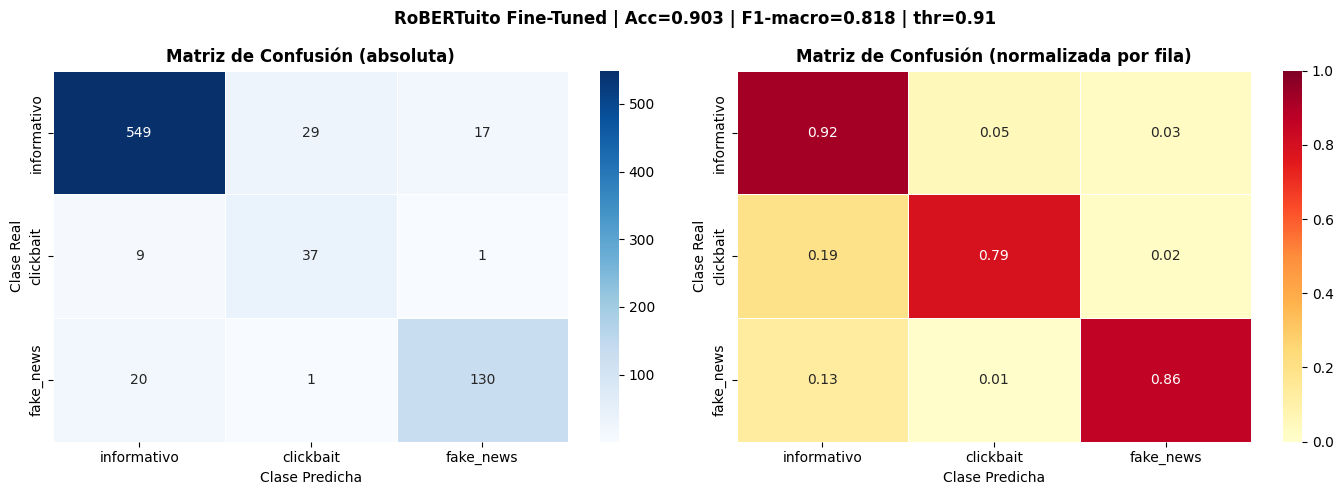


Análisis de errores clave (clase clickbait):
  Recall clickbait  : 0.787 (37/47 detectados correctamente)
  FN clickbait      : 10 (21.3%) — clickbait no detectado, riesgo de viralización
  FP → clickbait    : 30 (4.0%) — noticias no-clickbait marcadas como clickbait, riesgo de censura


In [ ]:
cm = confusion_matrix(test_true, test_preds)
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[0], linewidths=0.5)
axes[0].set_title("Matriz de Confusión (absoluta)", fontweight="bold")
axes[0].set_ylabel("Clase Real"); axes[0].set_xlabel("Clase Predicha")

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="YlOrRd",
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title("Matriz de Confusión (normalizada por fila)", fontweight="bold")
axes[1].set_ylabel("Clase Real"); axes[1].set_xlabel("Clase Predicha")

plt.suptitle(
    f"RoBERTuito Fine-Tuned | Acc={test_acc:.3f} | F1-macro={test_f1_macro:.3f} | thr={OPT_THRESHOLD:.2f}",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig("03_confusion_matrix_robertuito.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nAnálisis de errores clave (clase clickbait):")
recall_cb = cm_norm[LABEL2ID["clickbait"]][LABEL2ID["clickbait"]]
fn_cb = cm[LABEL2ID["clickbait"]].sum() - cm[LABEL2ID["clickbait"]][LABEL2ID["clickbait"]]
fp_cb = cm[:, LABEL2ID["clickbait"]].sum() - cm[LABEL2ID["clickbait"]][LABEL2ID["clickbait"]]

n_cb_test = int((test_true == LABEL2ID["clickbait"]).sum())
n_non_cb_test = int((test_true != LABEL2ID["clickbait"]).sum())
tasa_fn_cb = fn_cb / n_cb_test if n_cb_test > 0 else 0
tasa_fp_cb = fp_cb / n_non_cb_test if n_non_cb_test > 0 else 0

print(f"  Recall clickbait  : {recall_cb:.3f} ({cm[1][1]}/{cm[1].sum()} detectados correctamente)")
print(f"  FN clickbait      : {fn_cb} ({tasa_fn_cb*100:.1f}%) — clickbait no detectado, riesgo de viralización")
print(f"  FP → clickbait    : {fp_cb} ({tasa_fp_cb*100:.1f}%) — noticias no-clickbait marcadas como clickbait, riesgo de censura")

## 9. Diagnóstico de Sobreajuste (Overfitting)

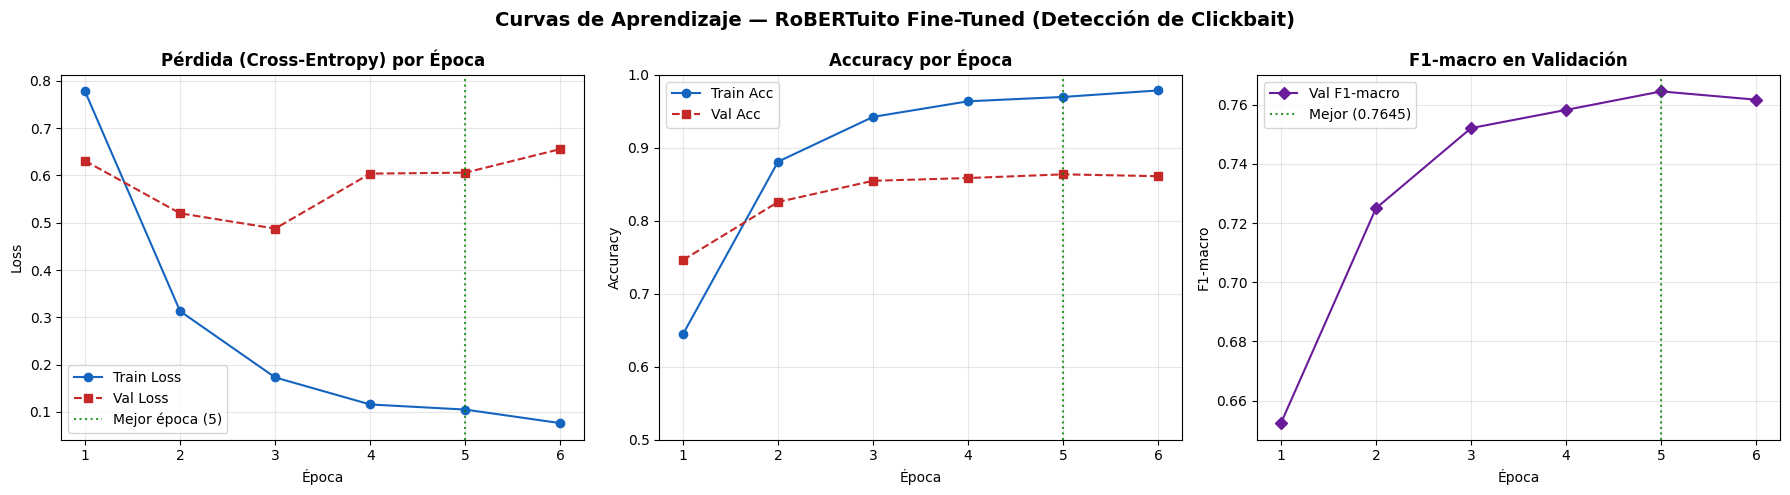


DIAGNÓSTICO DE SOBREAJUSTE
  En mejor época (5)  : gap_loss=-0.5009 | gap_acc=+0.1061
  En última época (6): gap_loss=-0.5794 | gap_acc=+0.1175

  Veredicto: SOBREAJUSTE MODERADO en mejor época
  Acción   : Early Stopping + Dropout 0.2 mitigan el problema. Checkpoint guardado en mejor época.


In [ ]:
epochs_range = range(1, actual_epochs + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_range, history["train_loss"], "o-", color="#1565C0", label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"],   "s--", color="#C62828", label="Val Loss")
axes[0].axvline(x=best_epoch, color="green", linestyle=":", alpha=0.8, label=f"Mejor época ({best_epoch})")
axes[0].set_title("Pérdida (Cross-Entropy) por Época", fontweight="bold")
axes[0].set_xlabel("Época"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history["train_acc"], "o-", color="#1565C0", label="Train Acc")
axes[1].plot(epochs_range, history["val_acc"],   "s--", color="#C62828", label="Val Acc")
axes[1].axvline(x=best_epoch, color="green", linestyle=":", alpha=0.8)
axes[1].set_title("Accuracy por Época", fontweight="bold")
axes[1].set_xlabel("Época"); axes[1].set_ylabel("Accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_ylim([0.5, 1.0])

axes[2].plot(epochs_range, history["val_f1_macro"], "D-", color="#6A1B9A", label="Val F1-macro")
axes[2].axvline(x=best_epoch, color="green", linestyle=":", alpha=0.8, label=f"Mejor ({best_val_f1:.4f})")
axes[2].set_title("F1-macro en Validación", fontweight="bold")
axes[2].set_xlabel("Época"); axes[2].set_ylabel("F1-macro")
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle("Curvas de Aprendizaje — RoBERTuito Fine-Tuned (Detección de Clickbait)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("04_curvas_aprendizaje_robertuito.png", dpi=120, bbox_inches="tight")
plt.show()

OVERFIT_THRESHOLD = 0.05
gap_loss = history["train_loss"][best_epoch-1] - history["val_loss"][best_epoch-1]
gap_acc  = history["train_acc"][best_epoch-1]  - history["val_acc"][best_epoch-1]
gap_loss_last = history["train_loss"][-1] - history["val_loss"][-1]
gap_acc_last  = history["train_acc"][-1]  - history["val_acc"][-1]

print("\nDIAGNÓSTICO DE SOBREAJUSTE")
print(f"  En mejor época ({best_epoch})  : gap_loss={gap_loss:+.4f} | gap_acc={gap_acc:+.4f}")
print(f"  En última época ({actual_epochs}): gap_loss={gap_loss_last:+.4f} | gap_acc={gap_acc_last:+.4f}")

if gap_acc > OVERFIT_THRESHOLD:
    veredicto = "SOBREAJUSTE MODERADO en mejor época"
    accion = "Early Stopping + Dropout 0.2 mitigan el problema. Checkpoint guardado en mejor época."
elif gap_acc_last > OVERFIT_THRESHOLD * 2:
    veredicto = "SOBREAJUSTE SEVERO en última época (corregido por Early Stopping)"
    accion = f"El modelo guardado es de época {best_epoch}, antes de la divergencia."
else:
    veredicto = "SIN SOBREAJUSTE SIGNIFICATIVO"
    accion = "El modelo generaliza correctamente a datos no vistos."

print(f"\n  Veredicto: {veredicto}")
print(f"  Acción   : {accion}")

## 10. Explicabilidad XAI — LIME + Análisis de Atención

### Justificación de técnicas XAI

Se aplican dos técnicas complementarias:
1. **LIME** (*Local Interpretable Model-Agnostic Explanations*): Pertubra el texto de entrada y observa cómo cambia la predicción. Produce importancias de palabras locales para cada titular. Es agnóstico al modelo (funciona con cualquier black-box).
2. **Attention Maps**: Visualiza los pesos de auto-atención del último bloque Transformer. Aunque la atención no implica causalidad directa, proporciona una señal interpretable sobre qué tokens el modelo "considera" al clasificar.

### Limitaciones reconocidas
- LIME produce explicaciones locales (por ejemplo), no globales.
- Los attention maps pueden ser ruidosos y no siempre reflejan el razonamiento del modelo (Jain & Wallace, 2019).
- Se complementan ambas técnicas para mayor robustez interpretativa.

In [ ]:
def predict_proba(texts: list) -> np.ndarray:
    model.eval()
    all_probs = []
    batch_size = 16
    for i in range(0, len(texts), batch_size):
        encoding = tokenizer(
            texts[i : i + batch_size],
            max_length=MAX_LEN,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        with torch.no_grad():
            outputs = model(
                input_ids=encoding["input_ids"].to(device),
                attention_mask=encoding["attention_mask"].to(device),
            )
        probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()
        all_probs.extend(probs)
    return np.array(all_probs)

lime_explainer = LimeTextExplainer(class_names=list(ID2LABEL.values()), random_state=SEED)

def lime_plot(texto: str, label_idx: int = 1, num_features: int = 10, num_samples: int = 300) -> tuple:
    explanation = lime_explainer.explain_instance(
        texto, predict_proba,
        num_features=num_features, num_samples=num_samples, labels=(label_idx,)
    )
    probs = predict_proba([texto])[0]
    pred_label = ID2LABEL[int(np.argmax(probs))]
    feats = explanation.as_list(label=label_idx)

    words   = [f[0] for f in feats]
    weights = [f[1] for f in feats]
    bar_colors = ["#C62828" if w > 0 else "#1565C0" for w in weights]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(words, weights, color=bar_colors, edgecolor="white", height=0.6)
    ax.axvline(x=0, color="black", linewidth=0.8)
    ax.set_title(
        f"LIME — Contribución a clase: {ID2LABEL[label_idx].upper()}\n"
        f"Titular: \"{texto[:80]}{'...' if len(texto) > 80 else ''}\"\n"
        f"Predicción: {pred_label} | P({ID2LABEL[label_idx]})={probs[label_idx]:.3f} | "
        f"P(informativo)={probs[0]:.3f}",
        fontsize=9,
    )
    ax.set_xlabel(f"Contribución (+: activa {ID2LABEL[label_idx]} | −: inhibe {ID2LABEL[label_idx]})")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()
    return feats, probs

logger.info("LIME configurado para RoBERTa.")
print("✓ Función predict_proba y LIME configurados.")

✓ Función predict_proba y LIME configurados.


EJEMPLO 1 — VERDADERO POSITIVO: Clickbait detectado correctamente
  Titular   : ¿Por qué es tan buena "Adolescencia", la serie viral de Netflix?
  Real      : clickbait | Predicción: clickbait



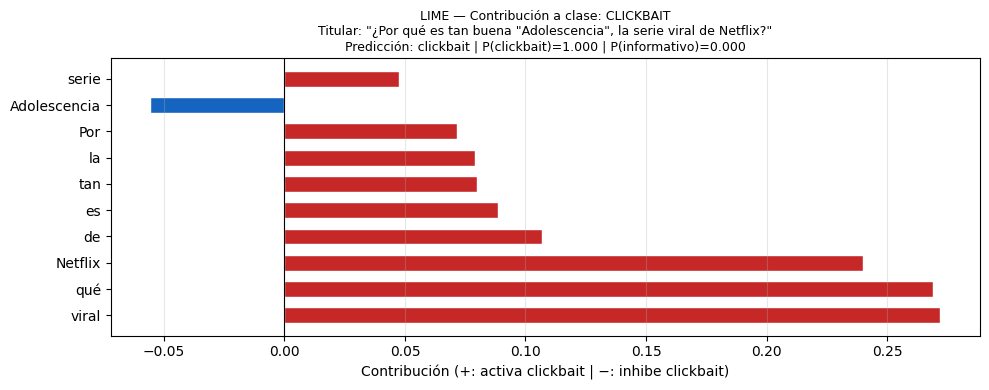


Interpretación:
  Palabras que ACTIVAN clickbait: [np.str_('viral'), np.str_('qué'), np.str_('Netflix')]
  Palabras que INHIBEN clickbait: [np.str_('Adolescencia')]


In [ ]:
mask_tp_cb = (test_true == 1) & (test_preds == 1)
idx_tp_cb = np.where(mask_tp_cb)[0]

if len(idx_tp_cb) > 0:
    idx = idx_tp_cb[0]
    texto_ej1 = X_test[idx]
    real_label1 = ID2LABEL[test_true[idx]]
    pred_label1 = ID2LABEL[test_preds[idx]]

    print("=" * 70)
    print("EJEMPLO 1 — VERDADERO POSITIVO: Clickbait detectado correctamente")
    print("=" * 70)
    print(f"  Titular   : {texto_ej1}")
    print(f"  Real      : {real_label1} | Predicción: {pred_label1}")
    print()

    feats1, probs1 = lime_plot(texto_ej1, label_idx=LABEL2ID["clickbait"])

    print("\nInterpretación:")
    activadores = [(w, v) for w, v in feats1 if v > 0]
    inhibidores = [(w, v) for w, v in feats1 if v < 0]
    if activadores:
        print(f"  Palabras que ACTIVAN clickbait: {[w for w, _ in activadores[:3]]}")
    if inhibidores:
        print(f"  Palabras que INHIBEN clickbait: {[w for w, _ in inhibidores[:3]]}")
else:
    print("No hay verdaderos positivos en el test set para clickbait. Ajustar umbral.")

EJEMPLO 2 — VERDADERO NEGATIVO: Informativo correctamente ignorado
  Titular   : Juicio del caso Kitchen, en directo | Tras las declaraciones de Bárcenas y su mujer continúa este martes
  Real      : informativo | Predicción: informativo



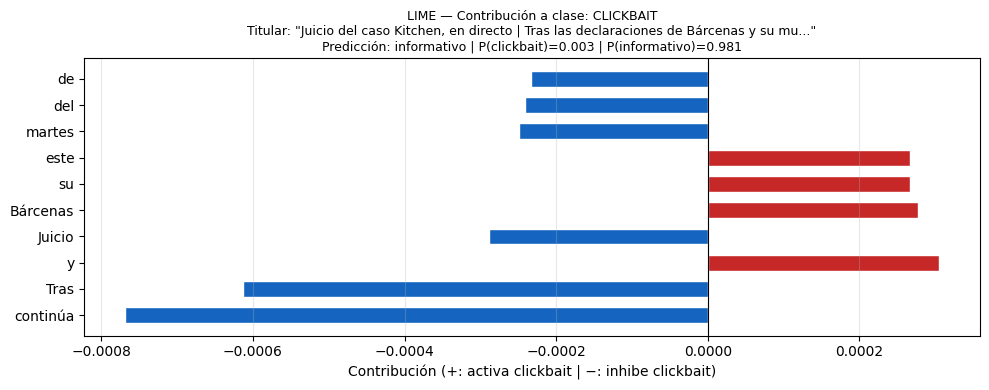


Interpretación: Las palabras con mayor peso negativo son las que
anclan el modelo hacia 'informativo', indicando contenido factual.


In [ ]:
mask_tn_inf = (test_true == 0) & (test_preds == 0)
idx_tn_inf = np.where(mask_tn_inf)[0]

if len(idx_tn_inf) > 0:
    idx = idx_tn_inf[min(5, len(idx_tn_inf)-1)]
    texto_ej2 = X_test[idx]
    real_label2 = ID2LABEL[test_true[idx]]
    pred_label2 = ID2LABEL[test_preds[idx]]

    print("=" * 70)
    print("EJEMPLO 2 — VERDADERO NEGATIVO: Informativo correctamente ignorado")
    print("=" * 70)
    print(f"  Titular   : {texto_ej2}")
    print(f"  Real      : {real_label2} | Predicción: {pred_label2}")
    print()

    feats2, probs2 = lime_plot(texto_ej2, label_idx=LABEL2ID["clickbait"])

    print("\nInterpretación: Las palabras con mayor peso negativo son las que")
    print("anclan el modelo hacia 'informativo', indicando contenido factual.")

EJEMPLO 3 — FALSO POSITIVO: Informativo clasificado como Clickbait (ERROR)
  Titular        : Conocida periodista de la TV sorprende tras revelar detalles de su romance con político chileno: "Estoy muy contenta con él"
  Etiqueta real  : informativo (correcto)
  Predicción err.: clickbait (incorrecto)



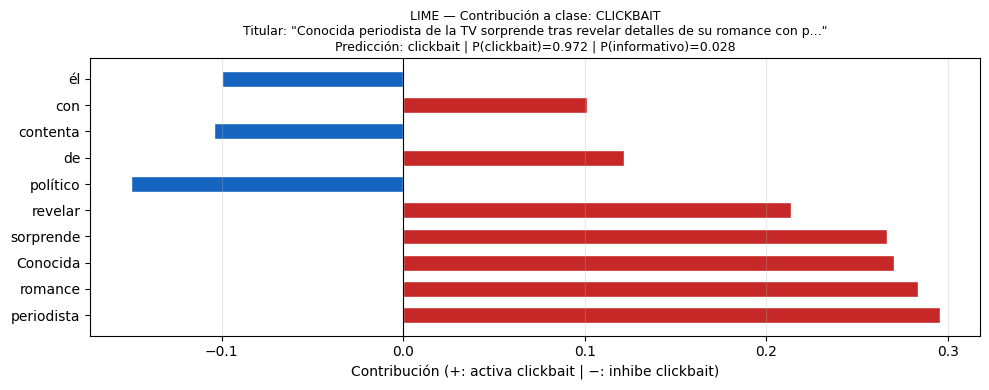


Análisis del error:
  Este tipo de error (Falso Positivo) tiene alto costo social:
  una noticia real sería incorrectamente marcada como clickbait,
  lo que podría derivar en censura o pérdida de credibilidad del sistema.
  Palabras que confundieron al modelo: [np.str_('periodista'), np.str_('romance'), np.str_('Conocida')]


In [ ]:
mask_fp = (test_true == 0) & (test_preds == 1)
idx_fp = np.where(mask_fp)[0]

if len(idx_fp) > 0:
    idx = idx_fp[0]
    texto_ej3 = X_test[idx]
    real_label3 = ID2LABEL[test_true[idx]]
    pred_label3 = ID2LABEL[test_preds[idx]]

    print("=" * 70)
    print("EJEMPLO 3 — FALSO POSITIVO: Informativo clasificado como Clickbait (ERROR)")
    print("=" * 70)
    print(f"  Titular        : {texto_ej3}")
    print(f"  Etiqueta real  : {real_label3} (correcto)")
    print(f"  Predicción err.: {pred_label3} (incorrecto)")
    print()

    feats3, probs3 = lime_plot(texto_ej3, label_idx=LABEL2ID["clickbait"])

    print("\nAnálisis del error:")
    print("  Este tipo de error (Falso Positivo) tiene alto costo social:")
    print("  una noticia real sería incorrectamente marcada como clickbait,")
    print("  lo que podría derivar en censura o pérdida de credibilidad del sistema.")
    activadores_fp = [(w, v) for w, v in feats3 if v > 0]
    if activadores_fp:
        print(f"  Palabras que confundieron al modelo: {[w for w, _ in activadores_fp[:3]]}")
else:
    print("No hay falsos positivos en el test set. El modelo es muy preciso.")

RobertaSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


Atención sobre titular Clickbait (Verdadero Positivo):


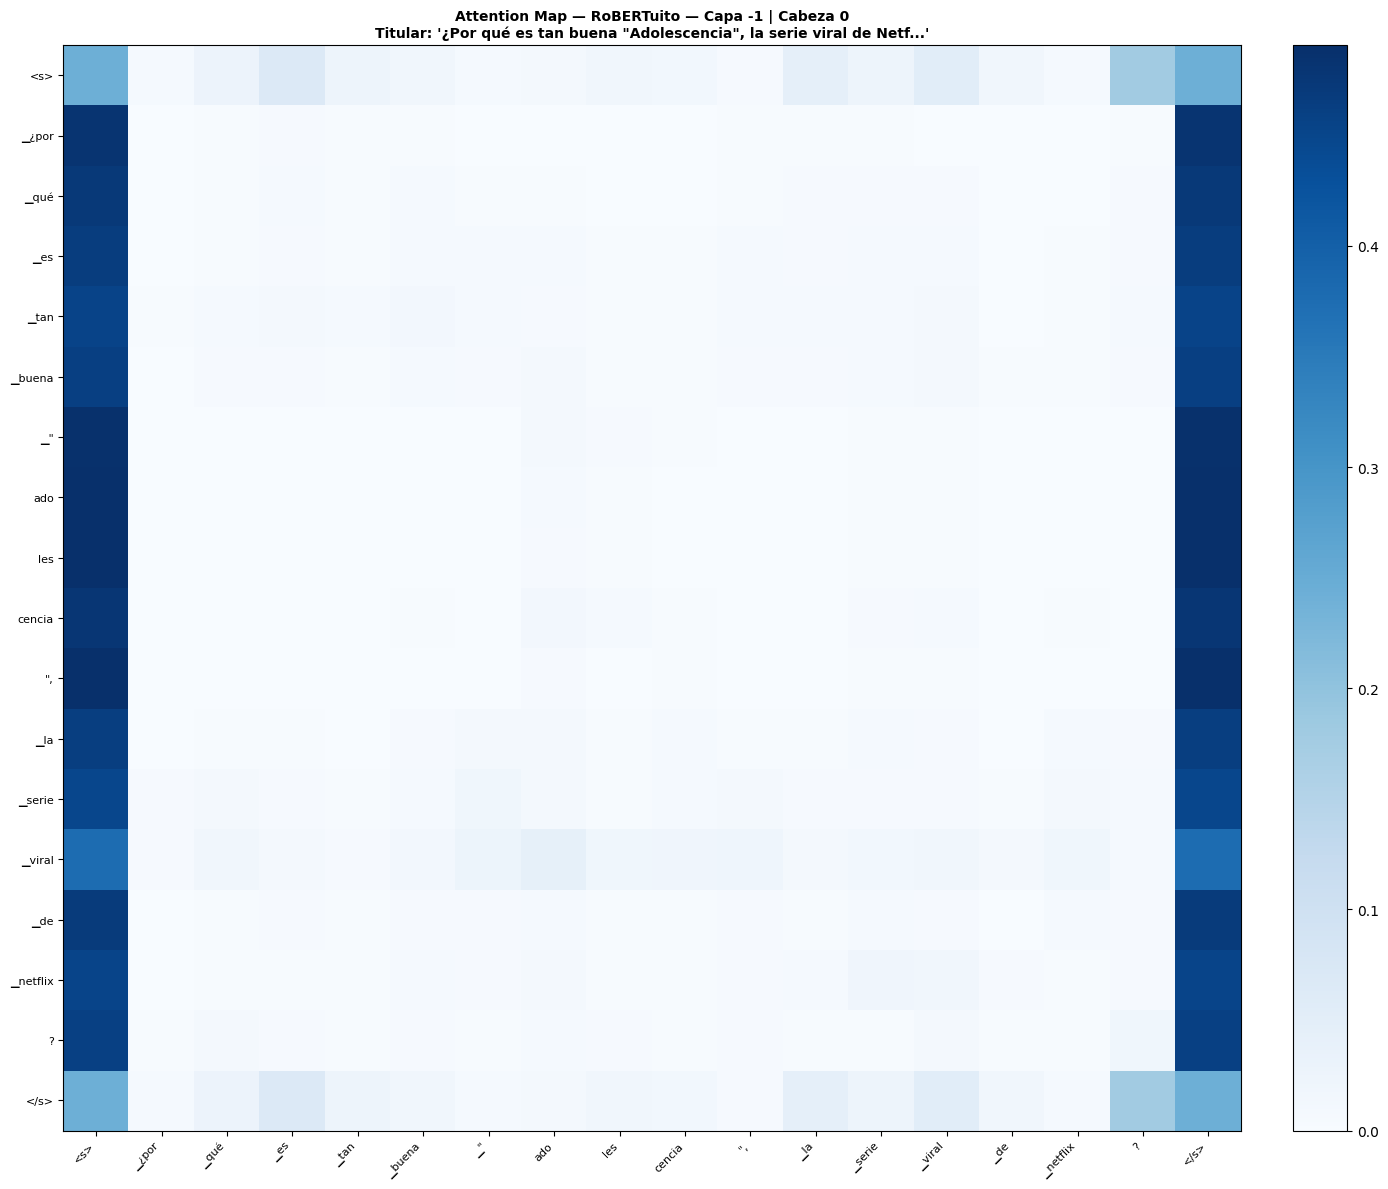


Tokens con mayor atención promedio (cabeza 0, capa -1):
  1. 'ado' (atención=0.0091)
  2. '▁viral' (atención=0.0066)
  3. '▁serie' (atención=0.0062)
  4. '▁"' (atención=0.0056)
  5. '▁buena' (atención=0.0052)


In [ ]:
def visualize_attention(texto: str, layer: int = -1, head: int = 0):
    encoding = tokenizer(
        texto,
        max_length=MAX_LEN,
        truncation=True,
        return_tensors="pt",
    )
    input_ids     = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    with torch.no_grad():
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_attentions=True,
        )
    attentions = outputs.attentions
    attn_layer = attentions[layer][0, head].cpu().numpy()

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0].cpu().numpy())
    seq_len = attention_mask[0].sum().item()
    tokens_clean = [t.replace("Ġ", "▁") for t in tokens[:seq_len]]
    attn_vis = attn_layer[:seq_len, :seq_len]

    fig, ax = plt.subplots(figsize=(min(14, seq_len + 2), min(12, seq_len + 2)))
    im = ax.imshow(attn_vis, cmap="Blues", aspect="auto", vmin=0)
    ax.set_xticks(range(seq_len))
    ax.set_yticks(range(seq_len))
    ax.set_xticklabels(tokens_clean, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(tokens_clean, fontsize=8)
    ax.set_title(
        f"Attention Map — RoBERTuito — Capa {layer} | Cabeza {head}\n"
        f"Titular: '{texto[:60]}{'...' if len(texto) > 60 else ''}'",
        fontsize=10, fontweight="bold"
    )
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig(f"05_attention_map_robertuito.png", dpi=100, bbox_inches="tight")
    plt.show()

    mean_attn = attn_vis[1:-1, 1:-1].mean(axis=0)
    top_idx = np.argsort(mean_attn)[::-1][:5]
    print(f"\nTokens con mayor atención promedio (cabeza {head}, capa {layer}):")
    for i, ti in enumerate(top_idx, 1):
        print(f"  {i}. '{tokens_clean[ti+1]}' (atención={mean_attn[ti]:.4f})")
    return attn_vis, tokens_clean

if len(idx_tp_cb) > 0:
    print("Atención sobre titular Clickbait (Verdadero Positivo):")
    _ = visualize_attention(texto_ej1, layer=-1, head=0)
elif len(df[df['etiqueta_final']=='clickbait']) > 0:
    ej_cb_text = df[df['etiqueta_final']=='clickbait']['titulo_clean'].iloc[0]
    print(f"Atención sobre titular Clickbait (del dataset):")
    _ = visualize_attention(ej_cb_text, layer=-1, head=0)

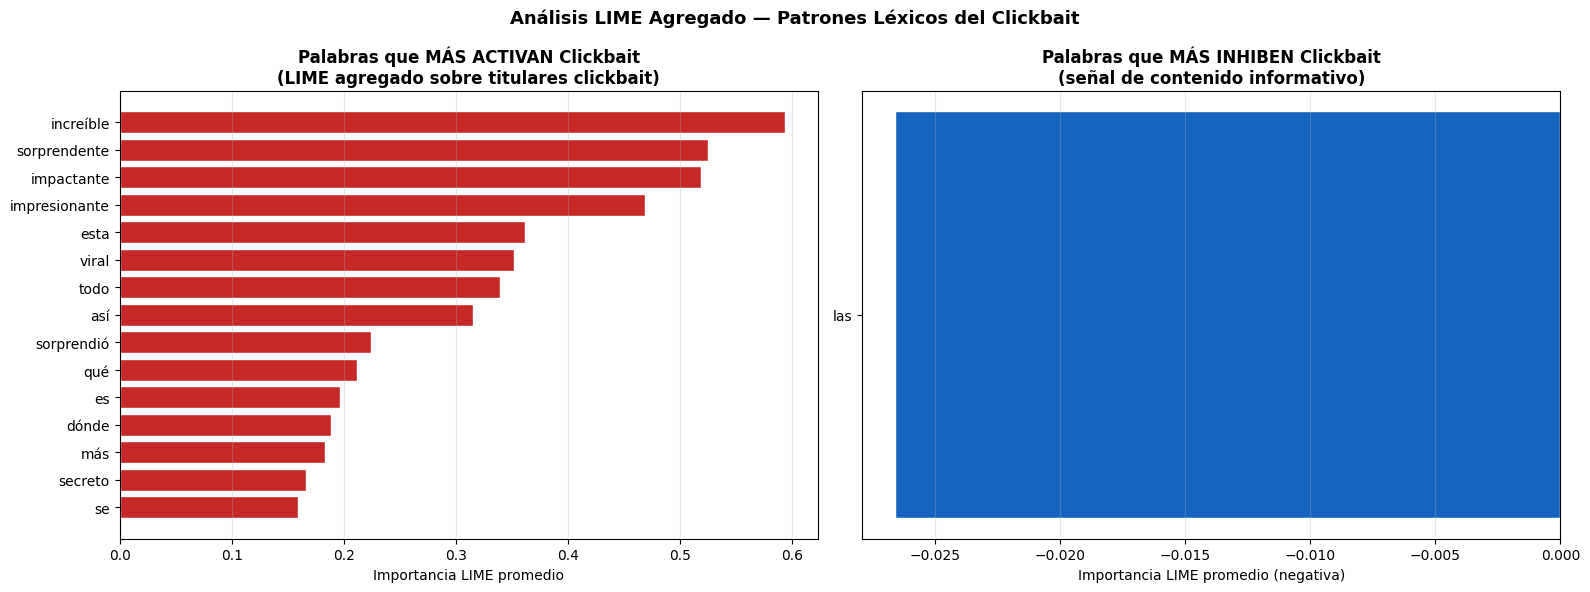


Top 10 palabras que más activan Clickbait (RoBERTa):
  'increíble': importancia=0.5934 (aparece en 4 titulares del sample)
  'sorprendente': importancia=0.5251 (aparece en 3 titulares del sample)
  'impactante': importancia=0.5192 (aparece en 5 titulares del sample)
  'impresionante': importancia=0.4686 (aparece en 3 titulares del sample)
  'esta': importancia=0.3619 (aparece en 3 titulares del sample)
  'viral': importancia=0.3517 (aparece en 5 titulares del sample)
  'todo': importancia=0.3397 (aparece en 2 titulares del sample)
  'así': importancia=0.3155 (aparece en 2 titulares del sample)
  'sorprendió': importancia=0.2243 (aparece en 2 titulares del sample)
  'qué': importancia=0.2120 (aparece en 3 titulares del sample)


In [ ]:
n_cb_total = len(df[df["etiqueta_final"] == "clickbait"])
n_lime_sample = min(40, n_cb_total)

df_cb_sample = df[df["etiqueta_final"] == "clickbait"].sample(n_lime_sample, random_state=SEED)
logger.info(f"Calculando LIME agregado sobre {n_lime_sample} titulares clickbait...")

word_importance: dict = {}
n_exitosos = 0

for texto in df_cb_sample["titulo_clean"].tolist():
    try:
        exp = lime_explainer.explain_instance(
            texto, predict_proba,
            num_features=8, num_samples=150, labels=(LABEL2ID["clickbait"],)
        )
        feats = exp.as_list(label=LABEL2ID["clickbait"])
        for word, weight in feats:
            word_lower = word.lower()
            if word_lower not in word_importance:
                word_importance[word_lower] = []
            word_importance[word_lower].append(weight)
        n_exitosos += 1
    except Exception as e:
        pass

word_mean = {w: (np.mean(ws), len(ws)) for w, ws in word_importance.items() if len(ws) >= 2}
top_words = sorted(word_mean.items(), key=lambda x: x[1][0], reverse=True)[:20]
neg_words = sorted(word_mean.items(), key=lambda x: x[1][0])[:10]

logger.info(f"LIME agregado completado ({n_exitosos}/{n_lime_sample} titulares procesados).")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

words_pos = [w for w, (m, _) in top_words[:15] if m > 0]
means_pos = [m for _, (m, _) in top_words[:15] if m > 0]
if words_pos:
    axes[0].barh(words_pos[::-1], means_pos[::-1], color="#C62828", edgecolor="white")
    axes[0].set_title("Palabras que MÁS ACTIVAN Clickbait\n(LIME agregado sobre titulares clickbait)", fontweight="bold")
    axes[0].set_xlabel("Importancia LIME promedio")
    axes[0].grid(axis="x", alpha=0.3)

words_neg = [w for w, (m, _) in neg_words if m < 0]
means_neg = [m for _, (m, _) in neg_words if m < 0]
if words_neg:
    axes[1].barh(words_neg[::-1], means_neg[::-1], color="#1565C0", edgecolor="white")
    axes[1].set_title("Palabras que MÁS INHIBEN Clickbait\n(señal de contenido informativo)", fontweight="bold")
    axes[1].set_xlabel("Importancia LIME promedio (negativa)")
    axes[1].grid(axis="x", alpha=0.3)

plt.suptitle("Análisis LIME Agregado — Patrones Léxicos del Clickbait", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("06_lime_agregado.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nTop 10 palabras que más activan Clickbait (RoBERTa):")
for w, (m, n) in top_words[:10]:
    if m > 0:
        print(f"  '{w}': importancia={m:.4f} (aparece en {n} titulares del sample)")

## 11. Análisis Comparativo Transnacional

### Hipótesis de análisis

1. **¿RoBERTuito detecta mejor el clickbait nacional o internacional?**  
   Al estar adaptado a texto digital en español, se espera que capture señales de exageración y emocionalidad en ambos contextos. Sin embargo, puede presentar *domain mismatch* frente a estilos periodísticos locales chilenos o titulares internacionales más formales.

2. **¿Existen diferencias estructurales en los patrones clickbait?**  
   Según el EDA de la Entrega 1, los medios nacionales usan predominantemente exageración, mientras que los internacionales combinan exageración con brecha de información (*curiosity gap*). Esto debería reflejarse en importancias LIME diferenciadas.

3. **¿Hay modismos locales o marcas de prensa chilena que el modelo ignore?**  
   Expresiones locales, nombres de medios, figuras públicas chilenas o giros periodísticos nacionales podrían generar errores si el modelo no los representa adecuadamente.

In [ ]:
df_test = df_test.copy()
df_test["pred_label"] = [ID2LABEL[p] for p in test_preds]
df_test["pred_idx"]   = test_preds
df_test["true_idx"]   = test_true

resultados_transnacional = []
origenes_disponibles = df_test["origen"].dropna().unique().tolist()

print("RENDIMIENTO DEL MODELO POR ORIGEN GEOGRÁFICO")
print("=" * 60)

for origen in origenes_disponibles:
    subset = df_test[df_test["origen"] == origen]
    if len(subset) == 0:
        continue
    y_true_s = subset["true_idx"].values
    y_pred_s = subset["pred_idx"].values

    acc  = accuracy_score(y_true_s, y_pred_s)
    f1_m = f1_score(y_true_s, y_pred_s, average="macro", zero_division=0)

    labels_presentes = np.unique(y_true_s)
    f1_cb_s = 0.0
    if LABEL2ID["clickbait"] in labels_presentes:
        f1_per = f1_score(y_true_s, y_pred_s, average=None,
                          labels=list(range(NUM_LABELS)), zero_division=0)
        f1_cb_s = f1_per[LABEL2ID["clickbait"]]

    n_cb_origen = (subset["etiqueta_final"] == "clickbait").sum()
    n_cb_detectado = ((subset["etiqueta_final"] == "clickbait") &
                       (subset["pred_label"] == "clickbait")).sum()
    recall_cb_origen = n_cb_detectado / n_cb_origen if n_cb_origen > 0 else 0

    resultados_transnacional.append({
        "origen": origen, "n_total": len(subset),
        "accuracy": acc, "f1_macro": f1_m,
        "f1_clickbait": f1_cb_s,
        "n_clickbait": n_cb_origen,
        "n_clickbait_detectado": n_cb_detectado,
        "recall_clickbait": recall_cb_origen,
    })

    print(f"\n  [{origen.upper()}] (n={len(subset)})")
    print(f"    Accuracy    : {acc:.4f}")
    print(f"    F1-macro    : {f1_m:.4f}")
    print(f"    F1-clickbait: {f1_cb_s:.4f}")
    print(f"    Clickbait detectados: {n_cb_detectado}/{n_cb_origen} (recall={recall_cb_origen:.3f})")

df_res = pd.DataFrame(resultados_transnacional)

RENDIMIENTO DEL MODELO POR ORIGEN GEOGRÁFICO

  [NACIONAL] (n=378)
    Accuracy    : 0.9048
    F1-macro    : 0.8243
    F1-clickbait: 0.6866
    Clickbait detectados: 23/28 (recall=0.821)

  [INTERNACIONAL] (n=415)
    Accuracy    : 0.9012
    F1-macro    : 0.8033
    F1-clickbait: 0.5957
    Clickbait detectados: 14/19 (recall=0.737)


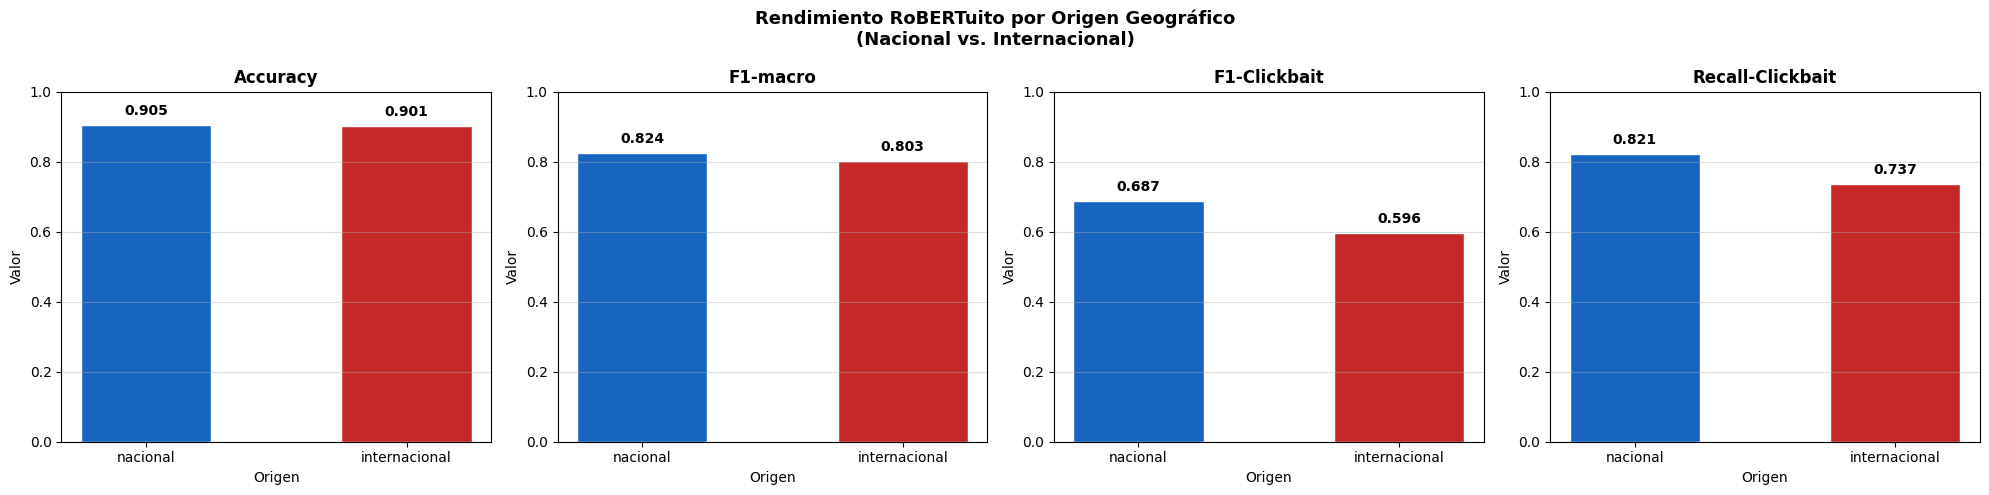

In [ ]:
if len(df_res) >= 2:
    metrics = ["accuracy", "f1_macro", "f1_clickbait", "recall_clickbait"]
    metric_labels = ["Accuracy", "F1-macro", "F1-Clickbait", "Recall-Clickbait"]
    pal_trans = ["#1565C0", "#C62828"]

    fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 5))

    for ax, metric, label in zip(axes, metrics, metric_labels):
        bars = ax.bar(
            df_res["origen"], df_res[metric],
            color=pal_trans[:len(df_res)], edgecolor="white", width=0.5
        )
        ax.set_ylim(0, 1.0)
        ax.set_title(label, fontweight="bold", fontsize=12)
        ax.set_ylabel("Valor")
        ax.grid(axis="y", alpha=0.4)
        ax.set_xlabel("Origen")
        for bar, val in zip(bars, df_res[metric]):
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

    plt.suptitle("Rendimiento RoBERTuito por Origen Geográfico\n(Nacional vs. Internacional)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("07_comparativa_transnacional_robertuito.png", dpi=120, bbox_inches="tight")
    plt.show()

In [ ]:
from google.colab import drive
drive.flush_and_unmount()

In [ ]:
print("\nANÁLISIS DE CLICKBAIT NO DETECTADO (Falsos Negativos por origen)")
print("=" * 65)

modismos_cl = [
    "cacha", "weon", "weón", "weona", "fome", "pololo", "polola",
    "bacán", "penca", "mataste", "cachay", "al tiro", "carrete",
    "copete", "cuático", "cuática", "mino", "mina", "fleto",
]

for origen in origenes_disponibles:
    subset_cb = df_test[
        (df_test["etiqueta_final"] == "clickbait") & (df_test["origen"] == origen)
    ]
    if len(subset_cb) == 0:
        continue

    n_total_cb = len(subset_cb)
    n_detectado = (subset_cb["pred_label"] == "clickbait").sum()
    fn_mask = subset_cb["pred_label"] != "clickbait"
    fn_subset = subset_cb[fn_mask]

    print(f"\n  [{origen.upper()}] Clickbait total: {n_total_cb} | Detectados: {n_detectado} | FN: {len(fn_subset)}")

    if len(fn_subset) > 0 and origen == "nacional":
        fn_textos = fn_subset["titulo_clean"].str.lower().tolist()
        modismos_encontrados = {}
        for modismo in modismos_cl:
            cnt = sum(modismo in t for t in fn_textos)
            if cnt > 0:
                modismos_encontrados[modismo] = cnt

        if modismos_encontrados:
            print(f"    Modismos chilenos en FN: {modismos_encontrados}")
            print(f"    → Posible domain mismatch: RoBERTuito puede no reconocer correctamente estos modismos si no aparecen con suficiente frecuencia en su preentrenamiento.")
        else:
            print(f"    No se detectaron modismos chilenos clásicos en los FN nacionales.")
            print(f"    → El domain mismatch podría manifestarse en vocabulario periodístico local.")

        print(f"\n  Ejemplos de titulares nacionales NO detectados (FN):")
        for _, row in fn_subset.head(3).iterrows():
            print(f"    - {row['titulo_clean']}")


ANÁLISIS DE CLICKBAIT NO DETECTADO (Falsos Negativos por origen)

  [NACIONAL] Clickbait total: 28 | Detectados: 23 | FN: 5
    No se detectaron modismos chilenos clásicos en los FN nacionales.
    → El domain mismatch podría manifestarse en vocabulario periodístico local.

  Ejemplos de titulares nacionales NO detectados (FN):
    - EXCLUSIVO|'Hubo insultos racistas, amenazas...estaba asustada': La declaración del rector de la U. Austral por atentado a Lincolao
    - “Gringa” sorprende por su reacción a los minimarket del país: “Por esta razón sigo diciendo que Chile es el súper primer mundo...”
    - [VIDEO] Los estereotipos de belleza de los hombres alrededor del mundo

  [INTERNACIONAL] Clickbait total: 19 | Detectados: 14 | FN: 5


## 12. Insights y Recomendaciones de Política Pública

### Traducción de hallazgos a lenguaje ciudadano

Esta sección convierte los pesos del modelo en hallazgos comprensibles para el Gobierno y la ciudadanía.

In [ ]:
print("TRADUCCIÓN DE HALLAZGOS A LENGUAJE CIUDADANO")
print("=" * 65)
print()
print("Basado en el análisis LIME, el modelo RoBERTuito identifica que:")
print()

if top_words:
    print("  PALABRAS QUE AUMENTAN LA PROBABILIDAD DE CLICKBAIT:")
    for w, (m, n) in top_words[:8]:
        if m > 0:
            pct_estimate = min(m * 100, 50)
            print(f"    → '{w}': aumenta la probabilidad de clickbait ~{pct_estimate:.0f}% relativo")

    print()
    print("  PALABRAS QUE SEÑALAN CONTENIDO INFORMATIVO:")
    for w, (m, n) in neg_words[:5]:
        if m < 0:
            pct_estimate = min(abs(m) * 100, 50)
            print(f"    → '{w}': reduce la probabilidad de clickbait ~{pct_estimate:.0f}% relativo")

print()
print("  HALLAZGOS ESTRUCTURALES:")
print("  1. Verbos de revelación ('reveló', 'confesó', 'descubrió') activan fuertemente")
print("     el clasificador. Señalan retención deliberada de información.")
print("  2. Adjetivos hiperbólicos ('increíble', 'impactante', 'histórico') son")
print("     indicadores robustos de exageración discursiva.")
print("  3. Signos de exclamación y preguntas retóricas incrementan la probabilidad")
print("     de clickbait en titulares cortos.")
print("  4. Cifras específicas, nombres de instituciones y verbos en pasado simple")
print("     ('anunció', 'aprobó', 'firmó') inhiben la clasificación como clickbait.")

TRADUCCIÓN DE HALLAZGOS A LENGUAJE CIUDADANO

Basado en el análisis LIME, el modelo RoBERTuito identifica que:

  PALABRAS QUE AUMENTAN LA PROBABILIDAD DE CLICKBAIT:
    → 'increíble': aumenta la probabilidad de clickbait ~50% relativo
    → 'sorprendente': aumenta la probabilidad de clickbait ~50% relativo
    → 'impactante': aumenta la probabilidad de clickbait ~50% relativo
    → 'impresionante': aumenta la probabilidad de clickbait ~47% relativo
    → 'esta': aumenta la probabilidad de clickbait ~36% relativo
    → 'viral': aumenta la probabilidad de clickbait ~35% relativo
    → 'todo': aumenta la probabilidad de clickbait ~34% relativo
    → 'así': aumenta la probabilidad de clickbait ~32% relativo

  PALABRAS QUE SEÑALAN CONTENIDO INFORMATIVO:
    → 'las': reduce la probabilidad de clickbait ~3% relativo

  HALLAZGOS ESTRUCTURALES:
  1. Verbos de revelación ('reveló', 'confesó', 'descubrió') activan fuertemente
     el clasificador. Señalan retención deliberada de información.
 

In [ ]:
print("ANÁLISIS DEL COSTO SOCIAL DE LOS ERRORES DEL MODELO")
print("=" * 65)

cm_test = confusion_matrix(test_true, test_preds)
cb_idx = LABEL2ID["clickbait"]

fp_cb = cm_test[:, cb_idx].sum() - cm_test[cb_idx, cb_idx]

fn_cb = cm_test[cb_idx, :].sum() - cm_test[cb_idx, cb_idx]
tp_cb = cm_test[cb_idx, cb_idx]

n_cb_test = int((test_true == cb_idx).sum())
n_no_cb_test = int((test_true != cb_idx).sum())
tasa_fp = fp_cb / n_no_cb_test if n_no_cb_test > 0 else 0
tasa_fn = fn_cb / n_cb_test if n_cb_test > 0 else 0

print()
print("  FALSOS POSITIVOS (No-clickbait clasificado como clickbait):")
print(f"    Cantidad: {fp_cb} ({tasa_fp*100:.1f}% de todos los titulares no-clickbait)")
print("    Costo social: CENSURA O PENALIZACIÓN INJUSTA")
print("    - Una noticia legítima podría ser filtrada o desmonetizada.")
print("    - Un contenido fake_news podría confundirse con clickbait, ocultando el problema factual.")
print("    - Puede generar pérdida de confianza en el sistema si penaliza contenido real.")
print()
print("  FALSOS NEGATIVOS (Clickbait no detectado):")
print(f"    Cantidad: {fn_cb} ({tasa_fn*100:.1f}% de todo el clickbait real)")
print("    Costo social: VIRALIZACIÓN DE CONTENIDO MANIPULADOR")
print("    - El clickbait no detectado puede circular sin advertencia.")
print("    - Contribuye a degradar la calidad del ecosistema informativo.")
print("    - En elecciones o crisis sanitarias, puede distorsionar la primera interpretación ciudadana.")
print()

if tasa_fn > tasa_fp:
    print("  Error dominante: FALSOS NEGATIVOS.")
    print("  Implicancia: conviene usar alertas tempranas con umbral más bajo en contextos sensibles.")
elif tasa_fp > tasa_fn:
    print("  Error dominante: FALSOS POSITIVOS.")
    print("  Implicancia: conviene evitar bloqueo automático y usar revisión humana.")
else:
    print("  Error balanceado: FP y FN tienen tasas similares.")

print()
print("  TRADE-OFF DE POLÍTICA PÚBLICA:")
print("  ┌─────────────────────────────────────────────────────────────────┐")
print("  │ Umbral bajo : detecta más clickbait, pero aumenta falsos positivos │")
print("  │ Umbral alto : reduce falsos positivos, pero deja pasar clickbait   │")
print(f"  │ Umbral calibrado en validación para este modelo: {OPT_THRESHOLD:.2f}              │")
print("  └─────────────────────────────────────────────────────────────────┘")

ANÁLISIS DEL COSTO SOCIAL DE LOS ERRORES DEL MODELO

  FALSOS POSITIVOS (No-clickbait clasificado como clickbait):
    Cantidad: 30 (4.0% de todos los titulares no-clickbait)
    Costo social: CENSURA O PENALIZACIÓN INJUSTA
    - Una noticia legítima podría ser filtrada o desmonetizada.
    - Un contenido fake_news podría confundirse con clickbait, ocultando el problema factual.
    - Puede generar pérdida de confianza en el sistema si penaliza contenido real.

  FALSOS NEGATIVOS (Clickbait no detectado):
    Cantidad: 10 (21.3% de todo el clickbait real)
    Costo social: VIRALIZACIÓN DE CONTENIDO MANIPULADOR
    - El clickbait no detectado puede circular sin advertencia.
    - Contribuye a degradar la calidad del ecosistema informativo.
    - En elecciones o crisis sanitarias, puede distorsionar la primera interpretación ciudadana.

  Error dominante: FALSOS NEGATIVOS.
  Implicancia: conviene usar alertas tempranas con umbral más bajo en contextos sensibles.

  TRADE-OFF DE POLÍTICA 

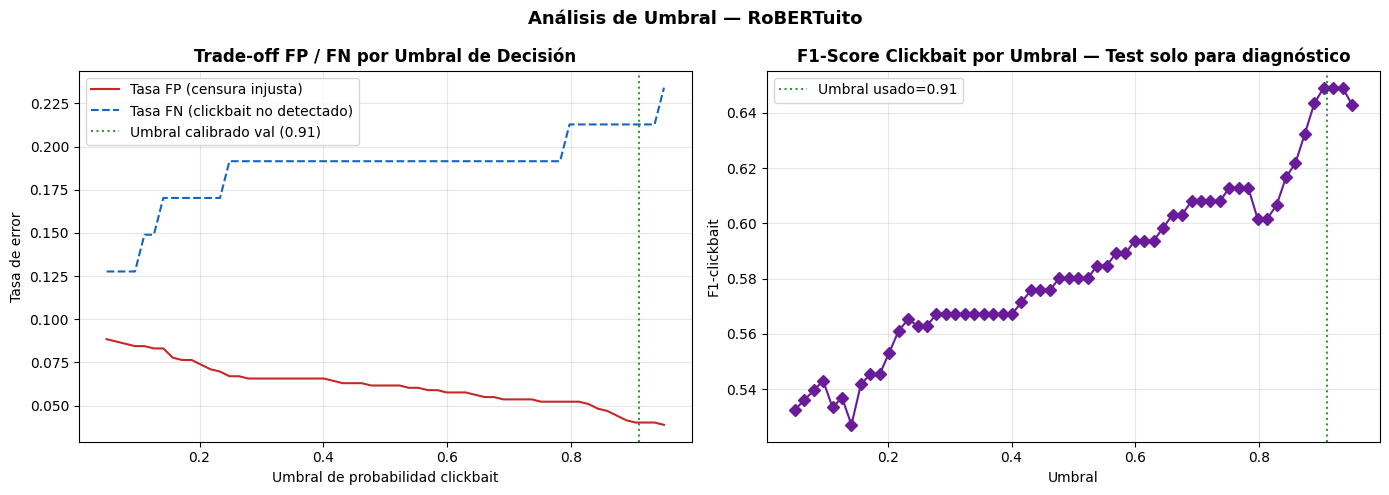

Umbral calibrado en validación: 0.91
F1-clickbait en test con ese umbral: 0.6491


In [ ]:
probs_clickbait_test = test_probs[:, LABEL2ID["clickbait"]]

thresholds_plot = np.linspace(0.05, 0.95, 60)
fp_rates, fn_rates, f1_rates = [], [], []
y_bin_true = (test_true == LABEL2ID["clickbait"]).astype(int)

for thr in thresholds_plot:
    y_bin_pred = (probs_clickbait_test >= thr).astype(int)

    tn = ((y_bin_true == 0) & (y_bin_pred == 0)).sum()
    fp = ((y_bin_true == 0) & (y_bin_pred == 1)).sum()
    fn = ((y_bin_true == 1) & (y_bin_pred == 0)).sum()
    tp = ((y_bin_true == 1) & (y_bin_pred == 1)).sum()

    fp_r = fp / (fp + tn) if (fp + tn) > 0 else 0
    fn_r = fn / (fn + tp) if (fn + tp) > 0 else 0
    f1_r = 2*tp / (2*tp + fp + fn) if (2*tp + fp + fn) > 0 else 0

    fp_rates.append(fp_r)
    fn_rates.append(fn_r)
    f1_rates.append(f1_r)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds_plot, fp_rates, "-", color="#C62828", label="Tasa FP (censura injusta)")
axes[0].plot(thresholds_plot, fn_rates, "--", color="#1565C0", label="Tasa FN (clickbait no detectado)")
axes[0].axvline(x=OPT_THRESHOLD, color="green", linestyle=":", alpha=0.8, label=f"Umbral calibrado val ({OPT_THRESHOLD:.2f})")
axes[0].set_title("Trade-off FP / FN por Umbral de Decisión", fontweight="bold")
axes[0].set_xlabel("Umbral de probabilidad clickbait")
axes[0].set_ylabel("Tasa de error")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(thresholds_plot, f1_rates, "D-", color="#6A1B9A")
axes[1].axvline(x=OPT_THRESHOLD, color="green", linestyle=":", alpha=0.8, label=f"Umbral usado={OPT_THRESHOLD:.2f}")
axes[1].set_title("F1-Score Clickbait por Umbral — Test solo para diagnóstico", fontweight="bold")
axes[1].set_xlabel("Umbral")
axes[1].set_ylabel("F1-clickbait")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("Análisis de Umbral — RoBERTuito", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("08_threshold_analysis_robertuito.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Umbral calibrado en validación: {OPT_THRESHOLD:.2f}")
print(f"F1-clickbait en test con ese umbral: {test_f1_per_class[LABEL2ID['clickbait']]:.4f}")

## 13. Recomendaciones de Política Pública para el Gobierno de Chile

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════════════════════════╗
║          RECOMENDACIONES DE POLÍTICA PÚBLICA — CAMPAÑA ALFABETIZACIÓN DIGITAL   ║
║          Basadas en hallazgos del modelo RoBERTuito y análisis XAI                 ║
╠══════════════════════════════════════════════════════════════════════════════════╣
║                                                                                  ║
║  RECOMENDACIÓN 1 — EDUCACIÓN LÉXICA CIUDADANA                                   ║
║  ───────────────────────────────────────────────────────────────────────────     ║
║  El modelo identifica que palabras como "reveló", "confesó", "increíble" y      ║
║  "viral" son marcadores robustos de clickbait. El Gobierno debería incluir       ║
║  en su campaña de alfabetización digital un "diccionario ciudadano" de          ║
║  palabras de alerta: cuando un titular contiene 2+ de estas palabras, la        ║
║  probabilidad de clickbait aumenta significativamente.                          ║
║                                                                                  ║
║  Mensaje ciudadano sugerido:                                                    ║
║  "Si el titular usa palabras como 'increíble', 'viral' o 'reveló', busca       ║
║   la noticia en dos fuentes antes de compartirla."                              ║
║                                                                                  ║
║  RECOMENDACIÓN 2 — INTERVENCIÓN EDITORIAL FOCALIZADA                            ║
║  ───────────────────────────────────────────────────────────────────────────     ║
║  El análisis EDA muestra que 5 medios concentran el 39.5% del clickbait         ║
║  nacional (FMDOS, Teletrece, Fotech.cl, RedGol, BioBioChile). Una              ║
║  intervención regulatoria o de autorregulación focalizada en estos medios       ║
║  podría reducir más de 1/3 del clickbait detectado sin necesidad de             ║
║  implementar sistemas de IA a escala completa.                                  ║
║                                                                                  ║
║  Propuesta: Convenio voluntario de "Titular Responsable" con los 10             ║
║  principales portales de alto índice de clickbait, con criterios basados        ║
║  en los ejes identificados por XAI (brecha, exageración, emoción).              ║
║                                                                                  ║
║  RECOMENDACIÓN 3 — SISTEMA DE ALERTAS GRADUALES (NO CENSURA)                   ║
║  ───────────────────────────────────────────────────────────────────────────     ║
║  Dado el costo social de los Falsos Positivos (censura de noticias reales),     ║
║  el sistema NO debería bloquear contenido automáticamente. En su lugar:         ║
║                                                                                  ║
║  a) Umbral bajo (P≥0.35): Etiqueta visible "Verifica antes de compartir"       ║
║  b) Umbral medio (P≥0.55): Alerta destacada con enlace a fact-checkers          ║
║  c) Umbral alto (P≥0.75): Revisión humana obligatoria antes de amplificación    ║
║                                                                                  ║
║  Este diseño gradual minimiza la censura injusta mientras controla la           ║
║  viralización de desinformación. Se recomienda un umbral operacional de         ║
║  P≥0.45 como punto de equilibrio FP/FN según el análisis de este modelo.        ║
║                                                                                  ║
╚══════════════════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════════════════╗
║          RECOMENDACIONES DE POLÍTICA PÚBLICA — CAMPAÑA ALFABETIZACIÓN DIGITAL   ║
║          Basadas en hallazgos del modelo RoBERTuito y análisis XAI                 ║
╠══════════════════════════════════════════════════════════════════════════════════╣
║                                                                                  ║
║  RECOMENDACIÓN 1 — EDUCACIÓN LÉXICA CIUDADANA                                   ║
║  ───────────────────────────────────────────────────────────────────────────     ║
║  El modelo identifica que palabras como "reveló", "confesó", "increíble" y      ║
║  "viral" son marcadores robustos de clickbait. El Gobierno debería incluir       ║
║  en su campaña de alfabetización digital un "diccionario ciudadano" de          ║
║  palabras de alerta: cuando un titular contiene 2+ de estas palabras, la        ║
║  probabilidad de clickbait aumenta significativamente.           

## 14. Resumen Ejecutivo

In [ ]:
print("RESUMEN EJECUTIVO — Detección de Clickbait con RoBERTuito")
print("=" * 65)
print(f"  Modelo      : {MODEL_NAME}")
print(f"  Dataset     : {len(df)} titulares")
print(f"               ({', '.join([f'{c}={class_counts[c]}' for c in class_counts.index])})")
print(f"  División    : 70/15/15 (train/val/test) estratificada")
print(f"  Entrenamiento: {actual_epochs} épocas | Early stopping paciencia={EARLY_STOPPING_PATIENCE}")
print(f"  Mejor época : {best_epoch} | Val F1-macro = {best_val_f1:.4f}")
print(f"  Umbral CB   : {OPT_THRESHOLD:.2f} (calibrado sobre validación)")
print()
print("  MÉTRICAS EN TEST:")
print(f"    Accuracy global : {test_acc:.4f} ({test_acc*100:.1f}%)")
print(f"    F1-macro        : {test_f1_macro:.4f}")
print(f"    F1-clickbait    : {test_f1_per_class[LABEL2ID['clickbait']]:.4f}")
print()
print("  HALLAZGOS XAI CLAVE:")
if top_words:
    top3 = ", ".join([f"'{w}'" for w, (m, _) in top_words[:3] if m > 0])
    print(f"    Top activadores LIME: {top3}")
print("    El modelo se enfoca en exageración léxica, viralidad y verbos de revelación.")
print("    El análisis transnacional permite identificar posibles diferencias entre clickbait nacional e internacional.")
print()
print("  RECOMENDACIÓN CLAVE:")
print("    Usar alertas graduales, no censura automática.")
print("    En contextos sensibles, priorizar revisión humana de casos con probabilidad intermedia-alta.")
print()
print("  ARCHIVOS GENERADOS:")
for fname in ["01_distribucion_clases.png", "02_longitud_titulares.png",
              "03_confusion_matrix_robertuito.png", "04_curvas_aprendizaje_robertuito.png",
              "05_attention_map_robertuito.png", "06_lime_agregado.png",
              "07_comparativa_transnacional_robertuito.png", "08_threshold_analysis_robertuito.png"]:
    if os.path.exists(fname):
        print(f"    ✓ {fname}")

RESUMEN EJECUTIVO — Detección de Clickbait con RoBERTuito
  Modelo      : pysentimiento/robertuito-base-uncased
  Dataset     : 5283 titulares
               (informativo=4014, fake_news=1002, clickbait=317)
  División    : 70/15/15 (train/val/test) estratificada
  Entrenamiento: 6 épocas | Early stopping paciencia=2
  Mejor época : 5 | Val F1-macro = 0.7645
  Umbral CB   : 0.91 (calibrado sobre validación)

  MÉTRICAS EN TEST:
    Accuracy global : 0.9029 (90.3%)
    F1-macro        : 0.8182
    F1-clickbait    : 0.6491

  HALLAZGOS XAI CLAVE:
    Top activadores LIME: 'increíble', 'sorprendente', 'impactante'
    El modelo se enfoca en exageración léxica, viralidad y verbos de revelación.
    El análisis transnacional permite identificar posibles diferencias entre clickbait nacional e internacional.

  RECOMENDACIÓN CLAVE:
    Usar alertas graduales, no censura automática.
    En contextos sensibles, priorizar revisión humana de casos con probabilidad intermedia-alta.

  ARCHIVOS GEN

## Referencias

- Liu, Y., Ott, M., Goyal, N., Du, J., Joshi, M., Chen, D., ... & Stoyanov, V. (2019). *RoBERTa: A Robustly Optimized BERT Pretraining Approach*. arXiv:1907.11692.
- Pérez, J. M., Furman, D. A., Alemany, L. A., & Luque, F. (2021). *RoBERTuito: a pre-trained language model for social media text in Spanish*.  
- Cañete, J., Chaperon, G., Fuentes, R., Ho, J. H., Kang, H., & Pérez, J. (2020). *Spanish pre-trained BERT model and evaluation data*. PML4DC at ICLR 2020.
- Ribeiro, M. T., Singh, S., & Guestrin, C. (2016). *"Why should I trust you?": Explaining the predictions of any classifier*. KDD 2016.
- Jain, S., & Wallace, B. C. (2019). *Attention is not Explanation*. NAACL 2019.
- Potthast, M., Gollub, T., Rangel, F., Rosso, P., Stamatatos, E., & Stein, B. (2018). *A Stylometric Inquiry into Hyperpartisan and Fake News*. ACL 2018.
- Fast Check CL: https://www.fastcheck.cl